# Digicow Farmer Training Adoption
## Placed 11th on the Zindi LB


---

### Objective
Given a farmer's training session record, we predict the **probability** they will adopt an improved agricultural practice within:
- **7 days** of training
- **90 days** of training
- **120 days** of training


**Peer adoption is a strong signal.** If other farmers in the *same group, on the same day* adopted a practice, a given farmer is more likely to also adopt.

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import log_loss, roc_auc_score
from scipy.optimize import minimize_scalar, minimize
from scipy.special import expit, logit
from scipy.stats import rankdata, entropy as scipy_entropy
import subprocess, sys

import lightgbm as lgb
import catboost as cb

np.random.seed(42)

In [4]:
# Read in data
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')
prior = pd.read_csv('Prior.csv')
sub   = pd.read_csv('SampleSubmission.csv')


print(f"Train: {train.shape}, Test: {test.shape}, Prior: {prior.shape}")
train.head()

Train: (13536, 17), Test: (5621, 14), Prior: (44882, 17)


,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days,has_topic_trained_on,trainer,topics_list
0,ID_CENCC8,FAR_eqbhscj,2024-01-03,Female,Manual,Above 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,['TRA_szrwyfzz'],"[['Ndume App', 'Poultry Feeding']]"
1,ID_YTO0FF,FAR_qlwtyik,2024-01-03,Female,Manual,Above 35,GRP_zemrbsy,1,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Poultry Housing'], ['Poultry Housing']]"
2,ID_1476PE,FAR_somfzxp,2024-01-03,Female,Manual,Above 35,GRP_zmblxsw,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Asili Fertilizer (Organic)', 'Biosecurity I..."
3,ID_MLKLIR,FAR_ongcqyd,2024-01-03,Female,Manual,Above 35,GRP_psdrfni,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Poultry Products'], ['Record Keeping In Dai..."
4,ID_V5ZVTA,FAR_ztsbhhm,2024-01-03,Female,Ussd,Below 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,['TRA_szrwyfzz'],"[['Ndume App', 'Poultry Feeding']]"


In [5]:
# The three binary targets we are predicting
targets = ['adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days']
target_short = {'adopted_within_07_days': '07', 'adopted_within_90_days': '90', 'adopted_within_120_days': '120'}


Raw data stores some topics_list as **string-encoded Python objects** (e.g. `"['Topic A', 'Topic B']"`). We need parsers to convert them to real Python lists.

In [6]:
def parse_topics(x):
    """Convert a string-encoded list of topics into a flat deduplicated Python list."""
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            all_t = []
            for item in parsed:
                if isinstance(item, list): all_t.extend(item)  # handle nested lists
                else: all_t.append(item)
            return list(set(all_t))  # deduplicate
    except: pass
    return []

def extract_primary_trainer(x):
    """Return the first trainer name from a string-encoded list."""
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list) and len(parsed) > 0:
            return parsed[0]
        return str(x)
    except: return str(x)

def extract_all_trainers(x):
    """Return all trainer names as a list."""
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list): return parsed
        return [str(x)]
    except: return [str(x)]

print("Parsers defined")

Parsers defined


## Data Preprocessing

Before building features, we:
1. Parse dates
2. Extract topics, trainer, and calendar fields from `prior`
3. Define two recency cutoffs used later to compute "recent" vs "all-time" statistics

**Recency matters** because a farmer's behaviour in the last 3 months might be more predictive than their 2-year history.

In [7]:
prior['training_day'] = pd.to_datetime(prior['training_day'])
prior['topics_parsed'] = prior['topics_list'].apply(parse_topics)
prior['n_topics'] = prior['topics_parsed'].apply(len)
prior['primary_trainer'] = prior['trainer'].apply(extract_primary_trainer)
prior['quarter'] = prior['training_day'].dt.quarter
prior['month'] = prior['training_day'].dt.month

# Cutoffs for "recent" activity windows
prior_max_date = prior['training_day'].max()
recent_cutoff    = prior_max_date - pd.Timedelta(days=90)   # last 90 days
recent_cutoff_6m = prior_max_date - pd.Timedelta(days=180)  # last 6 months

print(f"Prior date range: {prior['training_day'].min().date()} → {prior_max_date.date()}")
print(f"Recent cutoff (90d): {recent_cutoff.date()}")
print(f"Recent cutoff (6m):  {recent_cutoff_6m.date()}")

Prior date range: 2024-01-03 → 2025-12-11
Recent cutoff (90d): 2025-09-12
Recent cutoff (6m):  2025-06-14


**Peer Adoption Index**

Adoption is **socially contagious**. If your peers in the same group adopted a practice on the day you were trained, you're much more likely to adopt too.


| Table | Key |
|---|---|
| `peer_group_date` | group + day |
| `peer_trainer_date` | trainer + day |
| `peer_county_date` | county + day |
| `peer_grp_week` | group + week |
| `peer_grp_month` | group + month |


In [9]:

# Group + Date peers
# For each (group, day), how many farmers were there? How many adopted?
peer_group_date = prior.groupby(['group_name', 'training_day']).agg(
    peer_gd_count    = ('ID', 'count'),
    peer_gd_7d_sum   = ('adopted_within_07_days', 'sum'),
    peer_gd_7d_mean  = ('adopted_within_07_days', 'mean'),
    peer_gd_90d_mean = ('adopted_within_90_days', 'mean'),
    peer_gd_120d_sum = ('adopted_within_120_days', 'sum'),
    peer_gd_120d_mean= ('adopted_within_120_days', 'mean'),
    peer_gd_has_topic= ('has_topic_trained_on', 'mean'),
).reset_index()
# Binary flag: did any peer in this group adopt on this day?
peer_group_date['peer_gd_any_7d']   = (peer_group_date['peer_gd_7d_sum'] > 0).astype(int)
peer_group_date['peer_gd_any_120d'] = (peer_group_date['peer_gd_120d_sum'] > 0).astype(int)
print(f"  Peer group+date combos: {len(peer_group_date)}")

# Trainer + Date peers
prior_trainer_date = prior.groupby(['primary_trainer', 'training_day']).agg(
    peer_td_count   = ('ID', 'count'),
    peer_td_7d_mean = ('adopted_within_07_days', 'mean'),
    peer_td_120d_mean=('adopted_within_120_days', 'mean'),
    peer_td_7d_sum  = ('adopted_within_07_days', 'sum'),
).reset_index()
peer_trainer_date = prior_trainer_date.copy()
peer_trainer_date['peer_td_any_7d'] = (peer_trainer_date['peer_td_7d_sum'] > 0).astype(int)

#County + Date peers
peer_county_date = prior.groupby(['county', 'training_day']).agg(
    peer_cd_count    = ('ID', 'count'),
    peer_cd_7d_mean  = ('adopted_within_07_days', 'mean'),
    peer_cd_120d_mean= ('adopted_within_120_days', 'mean'),
).reset_index()

# Group + Week / Month peers
prior['week_key']  = prior['training_day'].dt.isocalendar().year.astype(str) + '_' + prior['training_day'].dt.isocalendar().week.astype(str)
prior['month_key'] = prior['training_day'].dt.to_period('M').astype(str)

peer_grp_week = prior.groupby(['group_name', 'week_key']).agg(
    peer_gw_count   = ('ID', 'count'),
    peer_gw_7d_mean = ('adopted_within_07_days', 'mean'),
    peer_gw_120d_mean=('adopted_within_120_days', 'mean'),
    peer_gw_7d_sum  = ('adopted_within_07_days', 'sum'),
).reset_index()
peer_grp_week['peer_gw_any_7d'] = (peer_grp_week['peer_gw_7d_sum'] > 0).astype(int)

peer_grp_month = prior.groupby(['group_name', 'month_key']).agg(
    peer_gm_count   = ('ID', 'count'),
    peer_gm_7d_mean = ('adopted_within_07_days', 'mean'),
    peer_gm_120d_mean=('adopted_within_120_days', 'mean'),
    peer_gm_7d_sum  = ('adopted_within_07_days', 'sum'),
).reset_index()
peer_grp_month['peer_gm_any_7d'] = (peer_grp_month['peer_gm_7d_sum'] > 0).astype(int)

#  Test-period aggregates (May 2025 onward)
test_period_start = pd.to_datetime('2025-05-01')
prior_tp = prior[prior['training_day'] >= test_period_start]

grp_tp = prior_tp.groupby('group_name').agg(
    grp_tp_count = ('ID', 'count'),
    grp_tp_7d    = ('adopted_within_07_days', 'mean'),
    grp_tp_120d  = ('adopted_within_120_days', 'mean'),
).reset_index()

trainer_tp = prior_tp.copy()
trainer_tp['primary_trainer'] = trainer_tp['trainer'].apply(extract_primary_trainer)
trainer_tp = trainer_tp.groupby('primary_trainer').agg(
    trainer_tp_count = ('ID', 'count'),
    trainer_tp_7d    = ('adopted_within_07_days', 'mean'),
    trainer_tp_120d  = ('adopted_within_120_days', 'mean'),
).reset_index()

county_tp = prior_tp.groupby('county').agg(
    county_tp_count = ('ID', 'count'),
    county_tp_7d    = ('adopted_within_07_days', 'mean'),
    county_tp_120d  = ('adopted_within_120_days', 'mean'),
).reset_index()


  Peer group+date combos: 1547


In [10]:
trainer_tp.head()

,primary_trainer,trainer_tp_count,trainer_tp_7d,trainer_tp_120d
0,TRA_gertumxc,1857,0.00000,0.000000
1,TRA_kkzpfdtu,1119,0.02681,0.034853
2,TRA_rkvyofbh,1000,0.08500,0.143000
3,TRA_suiifsur,1748,0.00000,0.000000
4,TRA_ubcgvofe,822,0.00000,0.000000


In [13]:
county_tp.head()

,county,county_tp_count,county_tp_7d,county_tp_120d
0,CNT_fhdsoy,1000,0.08500,0.143000
1,CNT_hfhimd,102,0.00000,0.000000
2,CNT_mvqqmw,1119,0.02681,0.034853
3,CNT_rihpna,720,0.00000,0.000000
4,CNT_vvuukv,1857,0.00000,0.000000


**Topic Statistics**

Some training topics have higher adoption rates than others. We compute statistics at three levels:

1. **Individual topic stats** — e.g., "Topic X has 18% 120-day adoption rate"
2. **Topic combination stats** — some topic *pairs* perform differently than either alone
3. **Topic pair stats** — the best-performing pair in a session
4. **Topic IDF (Inverse Document Frequency)** — rare topics might be more specialised/impactful
5. **Farmer-topic affinity** — has *this farmer* historically adopted when trained on *this topic*?

The IDF formula is: `log(total_sessions / (topic_count + 1))` — same idea as in text mining (rare = more informative).

In [14]:

# Flatten all topic-level records into a long-format table
all_topic_recs = []
for _, row in prior.iterrows():
    for t in row['topics_parsed']:
        all_topic_recs.append({'topic': t,
                               'a7':   row['adopted_within_07_days'],
                               'a90':  row['adopted_within_90_days'],
                               'a120': row['adopted_within_120_days']})
topic_df = pd.DataFrame(all_topic_recs)

# Per-topic adoption rates
topic_stats = topic_df.groupby('topic').agg(
    topic_count  = ('a7',  'count'),
    topic_a7     = ('a7',  'mean'),
    topic_a90    = ('a90', 'mean'),
    topic_a120   = ('a120','mean'),
    topic_a7_std = ('a7',  'std'),
    topic_a120_std=('a120','std'),
).reset_index()

# Convert to dict for fast lookup during feature building
topic_stats_dict = {}
for _, r in topic_stats.iterrows():
    topic_stats_dict[r['topic']] = {
        'count': r['topic_count'], 'a7': r['topic_a7'], 'a90': r['topic_a90'], 'a120': r['topic_a120'],
        'a7_std':   r['topic_a7_std']   if pd.notna(r['topic_a7_std'])   else 0,
        'a120_std': r['topic_a120_std'] if pd.notna(r['topic_a120_std']) else 0,
    }

# Topic *combination* stats (the full set of topics covered in one session)
topic_combo_counts = {}
topic_combo_adopt  = {}
for _, row in prior.iterrows():
    combo = tuple(sorted(row['topics_parsed']))
    topic_combo_counts[combo] = topic_combo_counts.get(combo, 0) + 1
    if combo not in topic_combo_adopt:
        topic_combo_adopt[combo] = {'count': 0, 'a120_sum': 0, 'a7_sum': 0}
    topic_combo_adopt[combo]['count']   += 1
    topic_combo_adopt[combo]['a120_sum']+= row['adopted_within_120_days']
    topic_combo_adopt[combo]['a7_sum']  += row['adopted_within_07_days']

# Topic *pair* stats (every 2-topic combination within a session)
topic_pair_stats = {}
for _, row in prior.iterrows():
    topics = sorted(row['topics_parsed'])
    a120, a7 = row['adopted_within_120_days'], row['adopted_within_07_days']
    for i in range(len(topics)):
        for j in range(i+1, len(topics)):
            pair = (topics[i], topics[j])
            if pair not in topic_pair_stats:
                topic_pair_stats[pair] = {'count': 0, 'a120_sum': 0, 'a7_sum': 0}
            topic_pair_stats[pair]['count']   += 1
            topic_pair_stats[pair]['a120_sum']+= a120
            topic_pair_stats[pair]['a7_sum']  += a7

# IDF: rarer topics score higher (more specific signal)
total_sessions = len(prior)
topic_idf = {t: np.log(total_sessions / (s['count'] + 1)) for t, s in topic_stats_dict.items()}

# Farmer-topic affinity: "when THIS farmer was trained on THIS topic, did they adopt?"
farmer_topic_history = {}
for _, row in prior.iterrows():
    fn = row['farmer_name']
    if fn not in farmer_topic_history:
        farmer_topic_history[fn] = {}
    for t in row['topics_parsed']:
        if t not in farmer_topic_history[fn]:
            farmer_topic_history[fn][t] = {'count': 0, 'a120_sum': 0, 'a7_sum': 0}
        farmer_topic_history[fn][t]['count']   += 1
        farmer_topic_history[fn][t]['a120_sum']+= row['adopted_within_120_days']
        farmer_topic_history[fn][t]['a7_sum']  += row['adopted_within_07_days']

print(f"  {len(topic_stats_dict)} unique topics tracked")

  146 unique topics tracked


**Per-Farmer Historical Features**

This is the richest feature block. For each farmer we extract dozens of signals from their prior training history.

### Feature Categories

| Category | Examples |
|---|---|
| **Basic rates** | mean/std adoption over all history |
| **Recency** | exponential decay-weighted adoption — recent sessions matter more |
| **Streaks** | consecutive adoptions or non-adoptions |
| **Acceleration** | is adoption rate increasing lately? |
| **Topic affinity** | adoption rate when topic was trained vs. when it wasn't |
| **Cooperative** | adoption rate as a coop member vs. non-member |
| **Temporal** | weekday vs weekend, quarter, month patterns |
| **Transitions** | how often does adoption status flip? (stability signal) |
| **Burst** | maximum adoptions in any 3-session window |

### Decay Weighting
Instead of a simple average, we weight sessions exponentially by recency:
```
weight = exp(-0.693 × days_ago / half_life)
```
A half-life of 30 days means a session 30 days ago counts half as much as today's.

In [15]:
def _streak(arr):
    """Count trailing consecutive 1s (most recent adoption streak)."""
    s = 0
    for v in reversed(arr):
        if v == 1: s += 1
        else: break
    return s

def compute_farmer_prior(group):
    """
    Given all prior records for one farmer, compute ~80 historical features.
    Called via groupby('farmer_name').apply(...)
    """
    n = len(group)
    sg = group.sort_values('training_day')  # chronological order matters
    v7, v90, v120 = sg['adopted_within_07_days'].values, sg['adopted_within_90_days'].values, sg['adopted_within_120_days'].values

    last = sg['training_day'].max()
    days_ago = (last - sg['training_day']).dt.days.values.astype(float)

    def decay_avg(vals, hl):
        """Exponentially decay-weighted average. hl = half-life in days."""
        w = np.exp(-0.693 * days_ago / hl)
        w /= w.sum()
        return (vals * w).sum()

    span_days = (last - sg['training_day'].min()).days

    r = {
        # --- Raw counts and rates ---
        'prior_count':           n,
        'prior_adopt_7_mean':    v7.mean(),
        'prior_adopt_90_mean':   v90.mean(),
        'prior_adopt_120_mean':  v120.mean(),
        'prior_adopt_7_std':     v7.std() if n > 1 else 0,
        'prior_adopt_120_std':   v120.std() if n > 1 else 0,
        'prior_has_topic_mean':  group['has_topic_trained_on'].mean(),
        'prior_coop_mean':       group['belong_to_cooperative'].mean(),
        'prior_any_adopt_120':   int(v120.sum() > 0),
        'prior_any_adopt_7':     int(v7.sum() > 0),
        # --- Temporal anchors ---
        'prior_last_training':   last,
        'prior_first_training':  sg['training_day'].min(),
        # --- Recent sessions (last 2) ---
        'prior_last2_adopt_7':   v7[-2:].mean(),
        'prior_last2_adopt_120': v120[-2:].mean(),
        # --- Trend: did the last session improve on the first? ---
        'prior_trend_120':       (v120[-1] - v120[0]) if n > 1 else 0,
        # --- Adoption streaks ---
        'prior_streak_120':      _streak(v120),
        'prior_streak_7':        _streak(v7),
        # --- Training behaviour ---
        'prior_topic_diversity': len(set(t for tl in group['topics_parsed'] for t in tl)),
        'prior_adopt_7_sum':     int(v7.sum()),
        'prior_adopt_120_sum':   int(v120.sum()),
        # --- Decay-weighted rates (multiple half-lives) ---
        'prior_decay_adopt_7':      decay_avg(v7,   90),
        'prior_decay_adopt_90':     decay_avg(v90,  90),
        'prior_decay_adopt_120':    decay_avg(v120, 90),
        'prior_decay_short_120':    decay_avg(v120, 30),
        'prior_decay_long_120':     decay_avg(v120, 180),
        'prior_decay_short_7':      decay_avg(v7,   30),
        'prior_decay_7d_14day':     decay_avg(v7,   14),
        'prior_decay_7d_60day':     decay_avg(v7,   60),
        # --- Training frequency ---
        'prior_training_span_days': span_days,
        'prior_training_freq':      n / max(span_days / 30.0, 1.0),  # sessions per month
        'prior_n_distinct_trainers':sg['primary_trainer'].nunique(),
        'prior_last_trainer':       sg['primary_trainer'].iloc[-1],
        'prior_last_session_had_topic':    sg['has_topic_trained_on'].iloc[-1],
        'prior_last_session_adopted_120':  int(v120[-1]),
        'prior_last_session_adopted_7':    int(v7[-1]),
        'prior_n_groups':           sg['group_name'].nunique() if 'group_name' in sg.columns else 1,
    }

    # Last known adoption dates (used to compute "days since last adoption")
    adopted_120 = sg[sg['adopted_within_120_days'] == 1]['training_day']
    adopted_7   = sg[sg['adopted_within_07_days']  == 1]['training_day']
    r['prior_last_adopt_120_day'] = adopted_120.max() if len(adopted_120) > 0 else pd.NaT
    r['prior_last_adopt_7_day']   = adopted_7.max()   if len(adopted_7)   > 0 else pd.NaT

    # Acceleration: is recent rate higher than early rate?
    if n >= 4:
        c = max(1, n - 3)
        r['prior_adopt_accel_120'] = v120[c:].mean() - v120[:c].mean()
        r['prior_adopt_accel_7']   = v7[c:].mean()   - v7[:c].mean()
    else:
        r['prior_adopt_accel_120'] = r['prior_adopt_accel_7'] = 0.0

    # Topic-conditional rates
    wt  = sg[sg['has_topic_trained_on'] == 1]
    wot = sg[sg['has_topic_trained_on'] == 0]
    r['prior_adopt_120_when_topic']  = wt['adopted_within_120_days'].mean() if len(wt)  > 0 else np.nan
    r['prior_adopt_7_when_topic']    = wt['adopted_within_07_days'].mean()  if len(wt)  > 0 else np.nan
    r['prior_adopt_120_no_topic']    = wot['adopted_within_120_days'].mean()if len(wot) > 0 else np.nan
    r['prior_adopt_7_no_topic']      = wot['adopted_within_07_days'].mean() if len(wot) > 0 else np.nan

    # Entropy: how uncertain is this farmer's adoption? (0 = always/never, 1 = 50/50)
    p_a  = v120.mean()
    r['prior_adopt_entropy_120'] = scipy_entropy([p_a, 1-p_a], base=2) if 0 < p_a < 1 else 0.0
    p7_a = v7.mean()
    r['prior_adopt_entropy_7']   = scipy_entropy([p7_a, 1-p7_a], base=2) if 0 < p7_a < 1 else 0.0

    # Cross-horizon: given adopted at 120d, what's 7d rate?
    m120 = sg['adopted_within_120_days'] == 1
    r['prior_upgrade_rate_7_given_120'] = sg.loc[m120, 'adopted_within_07_days'].mean() if m120.sum() > 0 else np.nan

    r['prior_7d_rate_last3'] = v7[-3:].mean()
    r['prior_7d_rate_last5'] = v7[-5:].mean()

    # Training gaps
    if n > 1:
        gaps = np.diff(sg['training_day'].sort_values().values).astype('timedelta64[D]').astype(float)
        r['prior_avg_training_gap_days'] = gaps.mean()
        r['prior_std_training_gap_days'] = gaps.std() if len(gaps) > 1 else 0
    else:
        r['prior_avg_training_gap_days'] = r['prior_std_training_gap_days'] = np.nan

    # First half vs second half of history
    if n >= 2:
        half = max(1, n // 2)
        r['prior_first_half_adopt_120']  = v120[:half].mean()
        r['prior_second_half_adopt_120'] = v120[half:].mean()
    else:
        r['prior_first_half_adopt_120'] = r['prior_second_half_adopt_120'] = v120.mean()

    # Longest non-adoption streak (consecutive zeros)
    lz = cz = 0
    for v in v120:
        if v == 0: cz += 1; lz = max(lz, cz)
        else: cz = 0
    r['prior_longest_no_adopt_streak'] = lz
    lz7 = cz7 = 0
    for v in v7:
        if v == 0: cz7 += 1; lz7 = max(lz7, cz7)
        else: cz7 = 0
    r['prior_longest_no_adopt_streak_7'] = lz7

    # How far into history was the first adoption?
    fi  = np.argmax(v120) if v120.sum() > 0 else -1
    r['prior_first_adopt_position'] = fi / max(n, 1) if fi >= 0 else np.nan
    fi7 = np.argmax(v7) if v7.sum() > 0 else -1
    r['prior_first_adopt_7_position'] = fi7 / max(n, 1) if fi7 >= 0 else np.nan

    # Transitions (flip-flop rate — stable adopters vs. inconsistent)
    if n > 1:
        tr120 = np.sum(np.abs(np.diff(v120)))
        r['prior_adopt_transitions_120']    = tr120
        r['prior_adopt_transition_rate']    = tr120 / (n - 1)
        tr7 = np.sum(np.abs(np.diff(v7)))
        r['prior_adopt_transitions_7']      = tr7
        r['prior_adopt_transition_rate_7']  = tr7 / (n - 1)
    else:
        r['prior_adopt_transitions_120'] = r['prior_adopt_transition_rate'] = 0
        r['prior_adopt_transitions_7']   = r['prior_adopt_transition_rate_7'] = 0

    r['prior_coop_changes'] = sg['belong_to_cooperative'].diff().abs().sum() if n > 1 else 0

    # Recent 6-month activity
    rm = sg['training_day'] >= recent_cutoff_6m
    if rm.sum() > 0:
        r['prior_adopt_120_recent_6m'] = sg.loc[rm, 'adopted_within_120_days'].mean()
        r['prior_adopt_7_recent_6m']   = sg.loc[rm, 'adopted_within_07_days'].mean()
        r['prior_count_recent_6m']     = rm.sum()
    else:
        r['prior_adopt_120_recent_6m'] = r['prior_adopt_7_recent_6m'] = np.nan
        r['prior_count_recent_6m'] = 0

    # Cooperative-conditioned rates
    cs  = sg[sg['belong_to_cooperative'] == 1]
    ncs = sg[sg['belong_to_cooperative'] == 0]
    r['prior_adopt_120_in_coop']   = cs['adopted_within_120_days'].mean()  if len(cs)  > 0 else np.nan
    r['prior_adopt_120_not_coop']  = ncs['adopted_within_120_days'].mean() if len(ncs) > 0 else np.nan
    r['prior_adopt_7_in_coop']     = cs['adopted_within_07_days'].mean()   if len(cs)  > 0 else np.nan
    r['prior_adopt_7_not_coop']    = ncs['adopted_within_07_days'].mean()  if len(ncs) > 0 else np.nan

    # Recency score: weighted presence of adoptions (more recent = higher score)
    rd = (last - sg['training_day']).dt.days.values.astype(float)
    r['prior_recency_score']    = np.mean(np.exp(-rd / 60.0))
    r['prior_7d_recency_score'] = np.sum(v7 * np.exp(-rd / 30.0)) / (np.sum(np.exp(-rd / 30.0)) + 1e-10)

    # Max adoption burst in any 3-session window
    if n >= 3:
        r['prior_max_adopt_burst_3']   = max(v120[i:i+3].sum() for i in range(n-2))
        r['prior_max_adopt_7_burst_3'] = max(v7[i:i+3].sum()   for i in range(n-2))
    else:
        r['prior_max_adopt_burst_3']   = v120.sum()
        r['prior_max_adopt_7_burst_3'] = v7.sum()

    # Cross-horizon ratios
    r['prior_adopt_90_to_120_ratio'] = (v90.mean() / (v120.mean() + 1e-10)) if v120.mean() > 0 else np.nan
    r['prior_7d_to_120d_ratio']      = (v7.mean()  / (v120.mean() + 1e-10)) if v120.mean() > 0 else np.nan

    # Multi-topic vs single-topic session performance
    mt = sg[sg['n_topics'] > 1]; st = sg[sg['n_topics'] <= 1]
    r['prior_adopt_120_multi_topic']  = mt['adopted_within_120_days'].mean() if len(mt) > 0 else np.nan
    r['prior_adopt_7_multi_topic']    = mt['adopted_within_07_days'].mean()  if len(mt) > 0 else np.nan
    r['prior_adopt_120_single_topic'] = st['adopted_within_120_days'].mean() if len(st) > 0 else np.nan
    r['prior_adopt_7_single_topic']   = st['adopted_within_07_days'].mean()  if len(st) > 0 else np.nan

    # Last non-adoption date
    na = sg[sg['adopted_within_120_days'] == 0]['training_day']
    r['prior_last_non_adopt_day'] = na.max() if len(na) > 0 else pd.NaT

    # Monotonicity of rolling mean (is the trend consistently up?)
    if n >= 3:
        rm120 = pd.Series(v120).rolling(min(3,n), min_periods=1).mean().values
        d = np.diff(rm120)
        r['prior_adopt_monotonicity']   = np.mean(d >= 0) if len(d) > 0 else 0.5
        rm7  = pd.Series(v7).rolling(min(3,n), min_periods=1).mean().values
        d7   = np.diff(rm7)
        r['prior_adopt_monotonicity_7'] = np.mean(d7 >= 0) if len(d7) > 0 else 0.5
    else:
        r['prior_adopt_monotonicity'] = r['prior_adopt_monotonicity_7'] = 0.5

    # Weekend vs weekday adoption
    sc = sg.copy(); sc['is_wknd'] = sc['training_day'].dt.dayofweek >= 5
    wk = sc[sc['is_wknd']]; wd = sc[~sc['is_wknd']]
    r['prior_adopt_120_weekend'] = wk['adopted_within_120_days'].mean() if len(wk) > 0 else np.nan
    r['prior_adopt_120_weekday'] = wd['adopted_within_120_days'].mean() if len(wd) > 0 else np.nan
    r['prior_adopt_7_weekend']   = wk['adopted_within_07_days'].mean()  if len(wk) > 0 else np.nan
    r['prior_adopt_7_weekday']   = wd['adopted_within_07_days'].mean()  if len(wd) > 0 else np.nan

    # Training intensity trend (more sessions in latter half?)
    if span_days > 60:
        mid  = sg['training_day'].iloc[0] + pd.Timedelta(days=span_days // 2)
        fc   = (sg['training_day'] <= mid).sum(); sc2 = n - fc
        r['prior_intensity_trend'] = (sc2 / max(span_days/60, 1)) - (fc / max(span_days/60, 1))
    else:
        r['prior_intensity_trend'] = 0.0

    # Quarterly breakdown
    sq = sg.copy(); sq['quarter'] = sq['training_day'].dt.quarter
    qr  = sq.groupby('quarter')['adopted_within_120_days'].mean().to_dict()
    q7r = sq.groupby('quarter')['adopted_within_07_days'].mean().to_dict()
    for q in [1,2,3,4]:
        r[f'prior_adopt_120_q{q}'] = qr.get(q, np.nan)
        r[f'prior_adopt_7_q{q}']   = q7r.get(q, np.nan)

    return pd.Series(r)

# Apply to all farmers in Prior
farmer_prior = prior.groupby('farmer_name').apply(compute_farmer_prior).reset_index()
print(f"  Farmer prior shape: {farmer_prior.shape}")

  Farmer prior shape: (6719, 96)



Beyond individual farmer history, we compute statistics for the **social and institutional context** around each session:

- **Group priors:** adoption rates, trend, momentum, cohesion (variance across farmers in the group)
- **Trainer priors:** effectiveness, momentum, breadth (how many groups / counties served)
- **County priors:** regional baseline, recent trends
- **Cross-interaction tables:** farmer×group, trainer×county, group×cooperative, etc.

In [16]:
def group_trend(g, col='adopted_within_120_days'):
    """Compare second-half vs first-half adoption rate for a group."""
    sg = g.sort_values('training_day'); n = len(sg)
    if n < 2: return 0.0
    h = max(1, n//2)
    return sg[col].iloc[h:].mean() - sg[col].iloc[:h].mean()

In [17]:

gt120 = prior.groupby('group_name').apply(lambda g: group_trend(g, 'adopted_within_120_days')).reset_index()
gt120.columns = ['group_name', 'grp_adopt_trend_120']
gt7   = prior.groupby('group_name').apply(lambda g: group_trend(g, 'adopted_within_07_days')).reset_index()
gt7.columns   = ['group_name', 'grp_adopt_trend_7']

group_prior = prior.groupby('group_name').agg(
    grp_prior_count         = ('ID', 'count'),
    grp_prior_adopt_7_mean  = ('adopted_within_07_days', 'mean'),
    grp_prior_adopt_90_mean = ('adopted_within_90_days', 'mean'),
    grp_prior_adopt_120_mean= ('adopted_within_120_days', 'mean'),
    grp_prior_adopt_120_std = ('adopted_within_120_days', 'std'),
    grp_prior_adopt_7_std   = ('adopted_within_07_days', 'std'),
    grp_prior_n_farmers     = ('farmer_name', 'nunique'),
    grp_prior_has_topic_rate= ('has_topic_trained_on', 'mean'),
).reset_index().merge(gt120, on='group_name', how='left').merge(gt7, on='group_name', how='left')

In [18]:
# Farmer×Group performance (how does this farmer do in this specific group?)
fg_prior = prior.groupby(['farmer_name', 'group_name']).agg(
    fg_adopt_120_mean= ('adopted_within_120_days', 'mean'),
    fg_adopt_7_mean  = ('adopted_within_07_days', 'mean'),
    fg_count         = ('ID', 'count'),
).reset_index()

In [19]:
# Group cohesion: how consistent are individual farmer rates within the group?
fr_ig = prior.groupby(['group_name', 'farmer_name'])['adopted_within_120_days'].mean().reset_index()
gc    = fr_ig.groupby('group_name')['adopted_within_120_days'].agg(
    grp_cohesion_std='std', grp_cohesion_mean='mean').reset_index()
gc['grp_cohesion_std'] = gc['grp_cohesion_std'].fillna(0)
group_prior = group_prior.merge(gc, on='group_name', how='left')

# Group adoption rate segmented by cooperative membership
gc_coop = prior.groupby(['group_name', 'belong_to_cooperative']).agg(
    gc_adopt_120_mean= ('adopted_within_120_days', 'mean'),
    gc_adopt_7_mean  = ('adopted_within_07_days', 'mean'),
    gc_count         = ('ID', 'count'),
).reset_index()

In [20]:
# Group session frequency (sessions per month)
grp_session_freq = prior.groupby('group_name').apply(
    lambda g: len(g) / max((g['training_day'].max() - g['training_day'].min()).days / 30.0, 1.0)
).reset_index()
grp_session_freq.columns = ['group_name', 'grp_session_freq']
group_prior = group_prior.merge(grp_session_freq, on='group_name', how='left')

# Recent group performance and momentum
grp_recent = prior[prior['training_day'] >= recent_cutoff].groupby('group_name').agg(
    grp_recent_adopt_120= ('adopted_within_120_days', 'mean'),
    grp_recent_adopt_7  = ('adopted_within_07_days', 'mean'),
    grp_recent_count    = ('ID', 'count'),
).reset_index()
group_prior = group_prior.merge(grp_recent, on='group_name', how='left')

In [21]:
# Momentum = recent rate vs all-time rate
group_prior['grp_momentum_120'] = group_prior['grp_recent_adopt_120'].fillna(group_prior['grp_prior_adopt_120_mean']) - group_prior['grp_prior_adopt_120_mean']
group_prior['grp_momentum_7']   = group_prior['grp_recent_adopt_7'].fillna(group_prior['grp_prior_adopt_7_mean'])   - group_prior['grp_prior_adopt_7_mean']

# ── Trainer prior ──
trainer_prior = prior.groupby('primary_trainer').agg(
    trainer_prior_count          = ('ID', 'count'),
    trainer_prior_adopt_7_mean   = ('adopted_within_07_days', 'mean'),
    trainer_prior_adopt_90_mean  = ('adopted_within_90_days', 'mean'),
    trainer_prior_adopt_120_mean = ('adopted_within_120_days', 'mean'),
    trainer_prior_n_farmers      = ('farmer_name', 'nunique'),
).reset_index()

In [22]:
t_eff = prior[prior['adopted_within_120_days']==1].groupby('primary_trainer').agg(trainer_adopted_count=('ID','count')).reset_index()
trainer_prior = trainer_prior.merge(t_eff, on='primary_trainer', how='left')
trainer_prior['trainer_adopt_ratio'] = trainer_prior['trainer_adopted_count'].fillna(0) / (trainer_prior['trainer_prior_count'] + 1)

t_eff7 = prior[prior['adopted_within_07_days']==1].groupby('primary_trainer').agg(trainer_adopted_7_count=('ID','count')).reset_index()
trainer_prior = trainer_prior.merge(t_eff7, on='primary_trainer', how='left')
trainer_prior['trainer_adopt_7_ratio'] = trainer_prior['trainer_adopted_7_count'].fillna(0) / (trainer_prior['trainer_prior_count'] + 1)

In [23]:
t_recent = prior[prior['training_day'] >= recent_cutoff].groupby('primary_trainer').agg(
    trainer_recent_session_count= ('ID', 'count'),
    trainer_recent_farmer_count = ('farmer_name', 'nunique'),
    trainer_recent_adopt_7      = ('adopted_within_07_days', 'mean'),
    trainer_recent_adopt_120    = ('adopted_within_120_days', 'mean'),
).reset_index()
trainer_prior = trainer_prior.merge(t_recent, on='primary_trainer', how='left')
trainer_prior['trainer_momentum']   = trainer_prior['trainer_recent_adopt_120'].fillna(trainer_prior['trainer_prior_adopt_120_mean']) - trainer_prior['trainer_prior_adopt_120_mean']
trainer_prior['trainer_momentum_7'] = trainer_prior['trainer_recent_adopt_7'].fillna(trainer_prior['trainer_prior_adopt_7_mean'])   - trainer_prior['trainer_prior_adopt_7_mean']

In [24]:
t_grp = prior.groupby('primary_trainer')['group_name'].nunique().reset_index()
t_grp.columns = ['primary_trainer', 'trainer_n_groups']
trainer_prior = trainer_prior.merge(t_grp, on='primary_trainer', how='left')
trainer_prior['trainer_farmers_per_group'] = trainer_prior['trainer_prior_n_farmers'] / (trainer_prior['trainer_n_groups'].fillna(1).clip(lower=1))

ft_pairs = prior.groupby(['farmer_name', 'primary_trainer']).agg(
    ft_pair_count    = ('ID', 'count'),
    ft_pair_adopt_120= ('adopted_within_120_days', 'mean'),
    ft_pair_adopt_7  = ('adopted_within_07_days', 'mean'),
).reset_index()

In [25]:
# County prior
county_prior = prior.groupby('county').agg(
    county_prior_adopt_120_mean = ('adopted_within_120_days', 'mean'),
    county_prior_adopt_7_mean   = ('adopted_within_07_days', 'mean'),
    county_prior_adopt_90_mean  = ('adopted_within_90_days', 'mean'),
    county_prior_count          = ('ID', 'count'),
).reset_index()
c_recent = prior[prior['training_day'] >= recent_cutoff].groupby('county').agg(
    county_recent_adopt_120= ('adopted_within_120_days', 'mean'),
    county_recent_adopt_7  = ('adopted_within_07_days', 'mean'),
).reset_index()
county_prior = county_prior.merge(c_recent, on='county', how='left')
county_prior['county_momentum_120'] = county_prior['county_recent_adopt_120'].fillna(county_prior['county_prior_adopt_120_mean']) - county_prior['county_prior_adopt_120_mean']
county_prior['county_momentum_7']   = county_prior['county_recent_adopt_7'].fillna(county_prior['county_prior_adopt_7_mean'])   - county_prior['county_prior_adopt_7_mean']


In [26]:
#  Fine-grained cross-interaction tables
cq  = prior.groupby(['county','quarter']).agg(cq_adopt_120_mean=('adopted_within_120_days','mean'), cq_adopt_7_mean=('adopted_within_07_days','mean'), cq_count=('ID','count')).reset_index()
grp_topic_prior = prior[prior['has_topic_trained_on']==1].groupby('group_name').agg(grp_topic_adopt_120_mean=('adopted_within_120_days','mean'), grp_topic_adopt_7_mean=('adopted_within_07_days','mean'), grp_topic_count=('ID','count')).reset_index()
tc  = prior.groupby(['primary_trainer','county']).agg(tc_adopt_120_mean=('adopted_within_120_days','mean'), tc_adopt_7_mean=('adopted_within_07_days','mean'), tc_count=('ID','count')).reset_index()
grp_recency = prior.groupby('group_name')['training_day'].max().reset_index()
grp_recency.columns = ['group_name', 'grp_last_training_day']
fig = prior.groupby(['group_name','farmer_name'])['training_day'].max().reset_index()
fig.columns = ['group_name','farmer_name','farmer_last_in_grp']
fig['grp_recency_rank_norm'] = fig.groupby('group_name')['farmer_last_in_grp'].rank(ascending=False, method='average')
fig['grp_recency_rank_norm'] = fig.groupby('group_name')['grp_recency_rank_norm'].transform(lambda x: x / x.max())
feig = prior.groupby(['group_name','farmer_name']).agg(farmer_grp_session_count=('ID','count')).reset_index()
feig['farmer_exp_pctile_in_grp'] = feig.groupby('group_name')['farmer_grp_session_count'].rank(pct=True, method='average')
cg  = prior.groupby(['county','gender']).agg(cg_adopt_120_mean=('adopted_within_120_days','mean'), cg_adopt_7_mean=('adopted_within_07_days','mean'), cg_count=('ID','count')).reset_index()
ca  = prior.groupby(['county','age']).agg(ca_adopt_120_mean=('adopted_within_120_days','mean'), ca_count=('ID','count')).reset_index()
cc  = prior.groupby(['county','belong_to_cooperative']).agg(cc_adopt_120_mean=('adopted_within_120_days','mean'), cc_count=('ID','count')).reset_index()
gm  = prior.groupby(['group_name','month']).agg(gm_adopt_120_mean=('adopted_within_120_days','mean'), gm_adopt_7_mean=('adopted_within_07_days','mean'), gm_count=('ID','count')).reset_index()
ta  = prior.groupby(['primary_trainer','age']).agg(ta_adopt_120_mean=('adopted_within_120_days','mean'), ta_count=('ID','count')).reset_index()
tg  = prior.groupby(['primary_trainer','gender']).agg(tg_adopt_120_mean=('adopted_within_120_days','mean'), tg_count=('ID','count')).reset_index()
cnd = prior.groupby('county')['group_name'].nunique().reset_index(); cnd.columns = ['county','county_n_groups']
cnt = prior.groupby('county')['primary_trainer'].nunique().reset_index(); cnt.columns = ['county','county_n_trainers']
ga  = prior.groupby(['group_name','age']).agg(ga_adopt_120_mean=('adopted_within_120_days','mean'), ga_count=('ID','count')).reset_index()
prior['n_topics_bin'] = pd.cut(prior['n_topics'], bins=[-1,0,1,3,10,999], labels=[0,1,2,3,4]).astype(float)
ntopic_adopt = prior.groupby('n_topics_bin').agg(ntopic_bin_adopt_120=('adopted_within_120_days','mean'), ntopic_bin_adopt_7=('adopted_within_07_days','mean')).to_dict('index')
reg_adopt = prior.groupby('registration').agg(reg_adopt_120_mean=('adopted_within_120_days','mean'), reg_adopt_7_mean=('adopted_within_07_days','mean'), reg_count=('ID','count')).reset_index()


## Label Encoding


In [27]:
all_data_le = pd.concat([
    train[['group_name','trainer','county']],
    test[['group_name','trainer','county']],
    prior[['group_name','trainer','county']]
], ignore_index=True)

label_encoders = {}
for col in ['group_name', 'trainer', 'county']:
    le = LabelEncoder()
    le.fit(all_data_le[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique values")

  group_name: 1026 unique values
  trainer: 22 unique values
  county: 9 unique values


## Feature Builder (`build_features`)

This function takes a raw dataframe (train or test) and outputs a feature-rich dataframe by:
1. Computing base calendar features (month, quarter, weekday, cyclical encoding)
2. Merging all the lookup tables built above
3. Engineering derived / interaction features
4. Computing composite scores (weighted blends of signals)

### Key derived features
| Feature | Intuition |
|---|---|
| `days_since_last_prior` | Recency of farmer's last training |
| `log_prior_count` | Log-transform of count (diminishing returns) |
| `bayesian_adopt_est_120` | Shrink farmer rate toward global mean when data is sparse |
| `farmer_vs_grp_lift_120` | Is this farmer above or below their group baseline? |
| `decay_ratio_120` | Short-term vs long-term decay rate (acceleration signal) |
| `composite_peer_7d` | Weighted blend of all peer adoption signals |
| `composite_adopt_score` | Overall adoption likelihood index |

In [34]:
def topic_agg(topics, key, fn=np.mean):
    """Aggregate a topic statistic (e.g. 'a7') over a list of topics."""
    vals = [topic_stats_dict[t][key] for t in topics if t in topic_stats_dict]
    return fn(vals) if vals else np.nan

In [35]:
def build_features(df):
    data = df.copy()
    data['training_day']    = pd.to_datetime(data['training_day'])
    data['topics_parsed']   = data['topics_list'].apply(parse_topics)
    data['primary_trainer'] = data['trainer'].apply(extract_primary_trainer)
    data['n_topics']        = data['topics_parsed'].apply(len)

    # ── Encode categorical demographics ──
    data['gender_enc']       = (data['gender'] == 'Male').astype(int)
    data['age_enc']          = (data['age'] == 'Below 35').astype(int)
    data['registration_enc'] = (data['registration'] == 'Ussd').astype(int)

    # ── Calendar features ──
    data['month']        = data['training_day'].dt.month
    data['quarter']      = data['training_day'].dt.quarter
    data['is_weekend']   = (data['training_day'].dt.dayofweek >= 5).astype(int)
    data['day_of_week']  = data['training_day'].dt.dayofweek
    # Cyclical encoding: sin/cos prevents the model from seeing Jan and Dec as far apart
    data['month_sin']    = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos']    = np.cos(2 * np.pi * data['month'] / 12)
    data['day_of_month'] = data['training_day'].dt.day
    data['week_of_year'] = data['training_day'].dt.isocalendar().week.astype(int)
    data['week_key']     = data['training_day'].dt.isocalendar().year.astype(str) + '_' + data['training_day'].dt.isocalendar().week.astype(str)
    data['month_key']    = data['training_day'].dt.to_period('M').astype(str)

    # ── Merge peer features (V13 main innovation) ──
    data = data.merge(peer_group_date,   on=['group_name','training_day'],       how='left')
    data = data.merge(peer_trainer_date, on=['primary_trainer','training_day'],  how='left')
    data = data.merge(peer_county_date,  on=['county','training_day'],           how='left')
    data = data.merge(peer_grp_week,     on=['group_name','week_key'],           how='left')
    data = data.merge(peer_grp_month,    on=['group_name','month_key'],          how='left')
    data = data.merge(grp_tp,            on='group_name',                        how='left')
    data = data.merge(trainer_tp,        on='primary_trainer',                   how='left')
    data = data.merge(county_tp,         on='county',                            how='left')

    # ── Merge historical prior tables ──
    data = data.merge(farmer_prior,     on='farmer_name',                        how='left')
    data = data.merge(group_prior,      on='group_name',                         how='left')
    data = data.merge(trainer_prior,    on='primary_trainer',                    how='left')
    data = data.merge(county_prior,     on='county',                             how='left')
    data = data.merge(fg_prior,         on=['farmer_name','group_name'],          how='left')
    data = data.merge(cq,               on=['county','quarter'],                  how='left')
    data = data.merge(grp_topic_prior,  on='group_name',                         how='left')
    data = data.merge(tc,               on=['primary_trainer','county'],          how='left')
    data = data.merge(grp_recency,      on='group_name',                         how='left')
    data = data.merge(ft_pairs,         on=['farmer_name','primary_trainer'],     how='left')
    data = data.merge(fig[['group_name','farmer_name','grp_recency_rank_norm']], on=['group_name','farmer_name'], how='left')
    data = data.merge(gc_coop,          on=['group_name','belong_to_cooperative'],how='left')
    data = data.merge(feig[['group_name','farmer_name','farmer_exp_pctile_in_grp']], on=['group_name','farmer_name'], how='left')
    data = data.merge(ga,  on=['group_name','age'],          how='left')
    data = data.merge(cg,  on=['county','gender'],           how='left')
    data = data.merge(ca,  on=['county','age'],              how='left')
    data = data.merge(cc,  on=['county','belong_to_cooperative'], how='left')
    data = data.merge(gm,  on=['group_name','month'],        how='left')
    data = data.merge(ta,  on=['primary_trainer','age'],     how='left')
    data = data.merge(tg,  on=['primary_trainer','gender'],  how='left')
    data = data.merge(cnd, on='county',                      how='left')
    data = data.merge(cnt, on='county',                      how='left')
    data = data.merge(reg_adopt, on='registration',          how='left')

    # ── Derived time-since features ──
    data['grp_days_since_last']     = (data['training_day'] - pd.to_datetime(data['grp_last_training_day'])).dt.days
    data['log_grp_days_since_last'] = np.log1p(data['grp_days_since_last'].clip(lower=0).fillna(999))
    data['days_since_last_prior']   = (data['training_day'] - pd.to_datetime(data['prior_last_training'])).dt.days
    data['days_since_first_prior']  = (data['training_day'] - pd.to_datetime(data['prior_first_training'])).dt.days
    data['log_days_since_last']     = np.log1p(data['days_since_last_prior'].clip(lower=0).fillna(999))
    data['log_prior_count']         = np.log1p(data['prior_count'].fillna(0))
    data['days_since_last_adopt_120']  = (data['training_day'] - pd.to_datetime(data['prior_last_adopt_120_day'])).dt.days
    data['days_since_last_adopt_7']    = (data['training_day'] - pd.to_datetime(data['prior_last_adopt_7_day'])).dt.days
    data['log_days_since_adopt_120']   = np.log1p(data['days_since_last_adopt_120'].clip(lower=0).fillna(9999))
    data['log_days_since_adopt_7']     = np.log1p(data['days_since_last_adopt_7'].clip(lower=0).fillna(9999))

    # ── Topic-level features ──
    for key in ['a7','a90','a120']:
        data[f'topic_mean_{key}'] = data['topics_parsed'].apply(lambda x: topic_agg(x, key, np.mean))
        data[f'topic_max_{key}']  = data['topics_parsed'].apply(lambda x: topic_agg(x, key, np.max))
    data['topic_min_a7']   = data['topics_parsed'].apply(lambda x: topic_agg(x, 'a7',  np.min))
    data['topic_min_a120'] = data['topics_parsed'].apply(lambda x: topic_agg(x, 'a120', np.min))
    # Count-weighted average (high-frequency topics get more weight)
    data['topic_wmean_a7']   = data['topics_parsed'].apply(lambda x: np.average([topic_stats_dict[t]['a7']   for t in x if t in topic_stats_dict], weights=[topic_stats_dict[t]['count'] for t in x if t in topic_stats_dict]) if any(t in topic_stats_dict for t in x) else np.nan)
    data['topic_wmean_a120'] = data['topics_parsed'].apply(lambda x: np.average([topic_stats_dict[t]['a120'] for t in x if t in topic_stats_dict], weights=[topic_stats_dict[t]['count'] for t in x if t in topic_stats_dict]) if any(t in topic_stats_dict for t in x) else np.nan)

    def get_combo_stats(topics):
        combo  = tuple(sorted(topics))
        cnt_c  = topic_combo_counts.get(combo, 0)
        stats  = topic_combo_adopt.get(combo, None)
        if stats and stats['count'] > 0:
            return cnt_c, stats['a120_sum']/stats['count'], stats['a7_sum']/stats['count']
        return cnt_c, np.nan, np.nan
    cr = data['topics_parsed'].apply(get_combo_stats)
    data['topic_combo_freq']      = cr.apply(lambda x: x[0])
    data['topic_combo_adopt_120'] = cr.apply(lambda x: x[1])
    data['topic_combo_adopt_7']   = cr.apply(lambda x: x[2])

    def best_pair(topics):
        """Find the topic pair with highest adoption rate in this session."""
        ts = sorted(topics); b120 = b7 = np.nan
        for i in range(len(ts)):
            for j in range(i+1, len(ts)):
                p = (ts[i], ts[j])
                if p in topic_pair_stats:
                    s = topic_pair_stats[p]
                    r120 = s['a120_sum']/s['count']; r7 = s['a7_sum']/s['count']
                    if np.isnan(b120) or r120 > b120: b120 = r120
                    if np.isnan(b7)   or r7  > b7:   b7   = r7
        return b120, b7
    pr = data['topics_parsed'].apply(best_pair)
    data['topic_best_pair_a120'] = pr.apply(lambda x: x[0])
    data['topic_best_pair_a7']   = pr.apply(lambda x: x[1])
    data['topic_mean_idf'] = data['topics_parsed'].apply(lambda x: np.mean([topic_idf.get(t, 0) for t in x]) if x else np.nan)

    def farmer_topic_aff(row):
        fn, topics = row['farmer_name'], row['topics_parsed']
        if fn not in farmer_topic_history or not topics: return np.nan, np.nan
        r120, r7 = [], []
        for t in topics:
            if t in farmer_topic_history[fn] and farmer_topic_history[fn][t]['count'] > 0:
                r120.append(farmer_topic_history[fn][t]['a120_sum']/farmer_topic_history[fn][t]['count'])
                r7.append(farmer_topic_history[fn][t]['a7_sum']/farmer_topic_history[fn][t]['count'])
        return (np.mean(r120) if r120 else np.nan, np.mean(r7) if r7 else np.nan)
    ar = data.apply(farmer_topic_aff, axis=1)
    data['farmer_topic_affinity_120'] = ar.apply(lambda x: x[0])
    data['farmer_topic_affinity_7']   = ar.apply(lambda x: x[1])

    def topic_overlap_count(row):
        fn, topics = row['farmer_name'], row['topics_parsed']
        if fn not in farmer_topic_history or not topics: return 0
        return sum(1 for t in topics if t in farmer_topic_history[fn])
    data['farmer_topic_overlap']       = data.apply(topic_overlap_count, axis=1)
    data['farmer_topic_overlap_ratio'] = data['farmer_topic_overlap'] / (data['n_topics'] + 1e-10)

    # ── Indicator flags ──
    data['has_prior']             = data['prior_count'].notna().astype(int)
    data['is_new_farmer']         = (data['has_prior'] == 0).astype(int)
    data['same_trainer_as_last']  = (data['primary_trainer'] == data['prior_last_trainer']).astype(float)
    data.loc[data['prior_last_trainer'].isna(), 'same_trainer_as_last'] = np.nan
    data['day_of_year']           = data['training_day'].dt.dayofyear
    data['year_progress']         = data['day_of_year'] / 365.25
    data['is_month_start']        = (data['day_of_month'] <= 5).astype(int)
    data['is_month_end']          = (data['day_of_month'] >= 25).astype(int)

    # ── Interaction features ──
    data['has_topic_x_prior_adopt']   = data['has_topic_trained_on'] * data['prior_any_adopt_120'].fillna(0)
    data['coop_x_prior_adopt_120']    = data['belong_to_cooperative'] * data['prior_adopt_120_mean'].fillna(0)
    data['has_topic_x_coop']          = data['has_topic_trained_on'] * data['belong_to_cooperative']
    data['prior_decay_x_has_topic']   = data['prior_decay_adopt_120'].fillna(0) * data['has_topic_trained_on']
    data['grp_adopt_x_has_topic']     = data['grp_prior_adopt_120_mean'].fillna(0) * data['has_topic_trained_on']
    data['prior_x_grp_adopt']         = data['prior_adopt_120_mean'].fillna(0) * data['grp_prior_adopt_120_mean'].fillna(0)
    data['prior_x_trainer']           = data['prior_adopt_120_mean'].fillna(0) * data['trainer_prior_adopt_120_mean'].fillna(0)
    data['has_topic_x_n_topics']      = data['has_topic_trained_on'] * data['n_topics']
    data['streak_x_topic']            = data['prior_streak_120'].fillna(0) * data['has_topic_trained_on']
    data['streak_7_x_topic']          = data['prior_streak_7'].fillna(0) * data['has_topic_trained_on']
    data['prior_adopt_7_x_topic']     = data['prior_adopt_7_mean'].fillna(0) * data['has_topic_trained_on']
    data['decay_14d_7_x_topic']       = data['prior_decay_7d_14day'].fillna(0) * data['has_topic_trained_on']
    data['fg_adopt_x_topic']          = data['fg_adopt_120_mean'].fillna(0) * data['has_topic_trained_on']
    data['trainer_ratio_x_topic']     = data['trainer_adopt_ratio'].fillna(0) * data['has_topic_trained_on']
    data['county_x_grp']              = data['county_prior_adopt_120_mean'].fillna(0) * data['grp_prior_adopt_120_mean'].fillna(0)

    # ── Peer interaction features (V13 new) ──
    data['peer_7d_x_farmer_hist']    = data['peer_gd_7d_mean'].fillna(0) * data['prior_adopt_7_mean'].fillna(0)
    data['peer_7d_x_has_topic']      = data['peer_gd_7d_mean'].fillna(0) * data['has_topic_trained_on']
    data['peer_120d_x_farmer']       = data['peer_gd_120d_mean'].fillna(0) * data['prior_adopt_120_mean'].fillna(0)
    data['peer_any_7d_x_coop']       = data['peer_gd_any_7d'].fillna(0) * data['belong_to_cooperative']
    data['peer_gd_x_td']             = data['peer_gd_7d_mean'].fillna(0) * data['peer_td_7d_mean'].fillna(0)
    data['peer_week_x_topic']        = data['peer_gw_7d_mean'].fillna(0) * data['has_topic_trained_on']
    data['peer_month_x_topic']       = data['peer_gm_7d_mean'].fillna(0) * data['has_topic_trained_on']
    data['grp_tp_7d_x_topic']        = data['grp_tp_7d'].fillna(0) * data['has_topic_trained_on']
    data['trainer_tp_7d_x_farmer']   = data['trainer_tp_7d'].fillna(0) * data['prior_adopt_7_mean'].fillna(0)
    # Signal strength: how many peers adopted (not just whether any did)
    data['peer_7d_signal_strength']  = data['peer_gd_7d_sum'].fillna(0) * np.log1p(data['peer_gd_count'].fillna(0))

    # ── Higher-order / lift features ──
    data['farmer_vs_county_lift']    = data['prior_adopt_120_mean'].fillna(0) - data['county_prior_adopt_120_mean'].fillna(0)
    data['farmer_vs_grp_lift_120']   = data['prior_adopt_120_mean'].fillna(0) - data['grp_prior_adopt_120_mean'].fillna(0)
    data['farmer_vs_grp_lift_7']     = data['prior_adopt_7_mean'].fillna(0)   - data['grp_prior_adopt_7_mean'].fillna(0)
    data['adopt_density_120']        = data['prior_adopt_120_sum'].fillna(0) / (data['prior_training_span_days'].fillna(1).clip(lower=1) / 30.0)
    data['n_trainers']               = data['trainer'].apply(lambda x: len(extract_all_trainers(x)))
    data['is_multi_trainer']         = (data['n_trainers'] > 1).astype(int)

    # ── Label-encoded categoricals ──
    for col in ['group_name','trainer','county']:
        data[col + '_enc'] = label_encoders[col].transform(data[col].astype(str))

    # ── N-topics bin lookup ──
    data['n_topics_bin']       = pd.cut(data['n_topics'], bins=[-1,0,1,3,10,999], labels=[0,1,2,3,4]).astype(float)
    data['ntopic_bin_adopt_120'] = data['n_topics_bin'].map({k: v['ntopic_bin_adopt_120'] for k, v in ntopic_adopt.items()})
    data['ntopic_bin_adopt_7']   = data['n_topics_bin'].map({k: v['ntopic_bin_adopt_7']   for k, v in ntopic_adopt.items()})

    # ── Nonlinear transforms ──
    data['log_prior_adopt_120']  = np.log1p(data['prior_adopt_120_mean'].fillna(0) * 100)
    data['log_prior_adopt_7']    = np.log1p(data['prior_adopt_7_mean'].fillna(0) * 100)
    data['sqrt_prior_count']     = np.sqrt(data['prior_count'].fillna(0))
    data['prior_adopt_120_sq']   = data['prior_adopt_120_mean'].fillna(0) ** 2
    data['prior_adopt_7_sq']     = data['prior_adopt_7_mean'].fillna(0) ** 2
    data['farmer_to_grp_ratio']  = (data['prior_adopt_120_mean'].fillna(0) + 0.01) / (data['grp_prior_adopt_120_mean'].fillna(0) + 0.01)
    data['farmer_to_grp_ratio_7']= (data['prior_adopt_7_mean'].fillna(0) + 0.001) / (data['grp_prior_adopt_7_mean'].fillna(0) + 0.001)
    data['topic_lift_over_farmer'] = data['topic_mean_a120'].fillna(0) - data['prior_adopt_120_mean'].fillna(0)
    data['topic_lift_over_farmer_7']= data['topic_mean_a7'].fillna(0) - data['prior_adopt_7_mean'].fillna(0)
    data['decay_ratio_120']      = data['prior_decay_short_120'].fillna(0) / (data['prior_decay_long_120'].fillna(0) + 1e-10)
    data['decay_ratio_7']        = data['prior_decay_short_7'].fillna(0)   / (data['prior_decay_adopt_7'].fillna(0)  + 1e-10)
    data['decay_ratio_7_14vs60'] = data['prior_decay_7d_14day'].fillna(0)  / (data['prior_decay_7d_60day'].fillna(0) + 1e-10)
    data['farmer_count_vs_grp']  = data['prior_count'].fillna(0) / (data['grp_prior_count'].fillna(1) + 1)

    # ── Bayesian rate estimates (shrinkage toward global mean) ──
    # Formula: (count × farmer_rate + pseudo_count × global_rate) / (count + pseudo_count)
    gl120 = 0.0223; gl7 = 0.011
    data['bayesian_adopt_est_120'] = (data['prior_count'].fillna(0) * data['prior_adopt_120_mean'].fillna(0) + 5*gl120) / (data['prior_count'].fillna(0) + 5)
    data['bayesian_adopt_est_7']   = (data['prior_count'].fillna(0) * data['prior_adopt_7_mean'].fillna(0)  + 5*gl7)   / (data['prior_count'].fillna(0) + 5)

    data['days_since_last_non_adopt'] = (data['training_day'] - pd.to_datetime(data['prior_last_non_adopt_day'])).dt.days
    data['log_days_since_non_adopt']  = np.log1p(data['days_since_last_non_adopt'].clip(lower=0).fillna(9999))
    data['farmer_coop_matched_rate']  = np.where(data['belong_to_cooperative']==1, data['prior_adopt_120_in_coop'].fillna(data['prior_adopt_120_mean'].fillna(0)), data['prior_adopt_120_not_coop'].fillna(data['prior_adopt_120_mean'].fillna(0)))
    data['farmer_coop_matched_rate_7']= np.where(data['belong_to_cooperative']==1, data['prior_adopt_7_in_coop'].fillna(data['prior_adopt_7_mean'].fillna(0)),   data['prior_adopt_7_not_coop'].fillna(data['prior_adopt_7_mean'].fillna(0)))
    data['last_topic_x_last_adopt']   = data['prior_last_session_had_topic'].fillna(0) * data['prior_last_session_adopted_120'].fillna(0)
    data['last_topic_x_last_adopt_7'] = data['prior_last_session_had_topic'].fillna(0) * data['prior_last_session_adopted_7'].fillna(0)
    data['grp_avg_farmer_exp']        = data['grp_prior_count'].fillna(0) / (data['grp_prior_n_farmers'].fillna(1) + 1)
    data['farmer_more_exp']           = (data['prior_count'].fillna(0) > data['grp_avg_farmer_exp']).astype(float)
    data['trainer_gender_match']      = data['tg_adopt_120_mean'].fillna(data['trainer_prior_adopt_120_mean'].fillna(0))
    data['county_age_match']          = data['ca_adopt_120_mean'].fillna(data['county_prior_adopt_120_mean'].fillna(0))

    # ── Composite summary scores ──
    data['composite_adopt_score'] = (
        data['bayesian_adopt_est_120'] * 0.30 + data['topic_mean_a120'].fillna(0) * 0.20 +
        data['grp_prior_adopt_120_mean'].fillna(0) * 0.20 + data['trainer_prior_adopt_120_mean'].fillna(0) * 0.15 +
        data['county_prior_adopt_120_mean'].fillna(0) * 0.15
    )
    data['composite_7d_score'] = (
        data['bayesian_adopt_est_7'] * 0.30 + data['topic_mean_a7'].fillna(0) * 0.20 +
        data['grp_prior_adopt_7_mean'].fillna(0) * 0.20 + data['trainer_prior_adopt_7_mean'].fillna(0) * 0.15 +
        data['county_prior_adopt_7_mean'].fillna(0) * 0.15
    )
    # Composite peer score — weighted blend of all peer signals
    data['composite_peer_7d'] = (
        data['peer_gd_7d_mean'].fillna(0) * 0.50 + data['peer_td_7d_mean'].fillna(0) * 0.20 +
        data['peer_gw_7d_mean'].fillna(0) * 0.20 + data['peer_cd_7d_mean'].fillna(0) * 0.10
    )
    data['composite_peer_120d'] = (
        data['peer_gd_120d_mean'].fillna(0) * 0.50 + data['peer_td_120d_mean'].fillna(0) * 0.20 +
        data['peer_gw_120d_mean'].fillna(0) * 0.20 + data['peer_cd_120d_mean'].fillna(0) * 0.10
    )

    return data

In [36]:
train_feat = build_features(train)
test_feat  = build_features(test)
print(f"train_feat: {train_feat.shape}, test_feat: {test_feat.shape}")

train_feat: (13536, 352), test_feat: (5621, 349)



## Feature Selection & Array Preparation


In [37]:
EXCLUDE_COLS = {
    'ID', 'farmer_name', 'training_day', 'gender', 'registration', 'age',
    'group_name', 'trainer', 'county', 'subcounty', 'ward',
    'adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days',
    'has_topic_trained_on',
    'topics_list', 'topics_parsed', 'primary_trainer',
    'prior_last_training', 'prior_first_training', 'prior_last_adopt_120_day',
    'prior_last_adopt_7_day', 'prior_last_non_adopt_day', 'prior_last_trainer',
    'grp_last_training_day', 'week_key', 'month_key',
}

feature_cols = [c for c in train_feat.columns if c not in EXCLUDE_COLS]
feature_cols = ['has_topic_trained_on'] + feature_cols  # prepend as first feature

for c in feature_cols[:]:
    if train_feat[c].dtype == 'object' or str(train_feat[c].dtype).startswith('datetime'):
        feature_cols.remove(c)

# Sanity check
missing = [c for c in feature_cols if c not in train_feat.columns]
if missing:
    print(f" Missing {len(missing)} cols: {missing[:5]}")
    feature_cols = [c for c in feature_cols if c in train_feat.columns]

# Fill NaNs with -1 (signals "unknown" to tree models)
X_train_base = train_feat[feature_cols].fillna(-1).values
X_test_base  = test_feat[feature_cols].fillna(-1).values
print(f"Features: {len(feature_cols)}, Train: {X_train_base.shape}, Test: {X_test_base.shape}")

Features: 326, Train: (13536, 326), Test: (5621, 326)


## Cell 12 — Target Encoding

### Smoothing
Categories with few observations can have noisy estimates. We apply **Bayesian smoothing**:
```
smoothed_rate = (count × category_mean + smooth × global_mean) / (count + smooth)
```
With `smooth=10`, a category with 1 observation barely moves from the global mean.

In [38]:
N_FOLDS_TE = 5
te_cols_train, te_cols_test = {}, {}

for target in targets:
    y_full = train_feat[target].values
    gm     = y_full.mean()  # global mean fallback
    skf_te = StratifiedKFold(n_splits=N_FOLDS_TE, shuffle=True, random_state=99)

    for cat_col in ['group_name', 'primary_trainer', 'farmer_name', 'county']:
        for smooth in [10, 50]:  # two smoothing levels create two feature variants
            cn    = f'te_{cat_col}_{target}_s{smooth}'
            te_tr = np.full(len(train_feat), np.nan)

            for tr_idx, val_idx in skf_te.split(train_feat, y_full):
                fd    = train_feat.iloc[tr_idx]
                stats = fd.groupby(cat_col)[target].agg(['mean', 'count'])
                # Smoothed estimate
                sm    = (stats['count'] * stats['mean'] + smooth * gm) / (stats['count'] + smooth)
                te_tr[val_idx] = train_feat.iloc[val_idx][cat_col].map(sm).values

            te_tr = np.where(np.isnan(te_tr), gm, te_tr)  # fill unseen categories
            te_cols_train[cn] = te_tr

            # Test: use all train data
            fs  = train_feat.groupby(cat_col)[target].agg(['mean', 'count'])
            fsm = (fs['count'] * fs['mean'] + smooth * gm) / (fs['count'] + smooth)
            te_cols_test[cn] = test_feat[cat_col].map(fsm).fillna(gm).values

# Concatenate TE columns to base feature matrices
te_train_arr = np.column_stack(list(te_cols_train.values()))
te_test_arr  = np.column_stack(list(te_cols_test.values()))
X_train = np.hstack([X_train_base, te_train_arr])
X_test  = np.hstack([X_test_base,  te_test_arr])

print(f"After TE: Train={X_train.shape}, Test={X_test.shape}")

After TE: Train=(13536, 350), Test=(5621, 350)


## Calibration Utilities

Raw model probabilities are often **miscalibrated** — e.g., a model that predicts 0.9 might only be right 70% of the time. Calibration fixes this.

We implement four calibration methods:

| Method | How it works |
|---|---|
| **Platt scaling** | Fits a logistic regression on logit(probs) |
| **Beta calibration** | Fits logistic regression on log(p) and log(1-p) — more flexible |
| **Isotonic regression** | Non-parametric monotonic fit — very flexible but can overfit |
| **Temperature scaling** | Divides logits by a learned scalar T. T>1 softens; T<1 sharpens |

The final calibrated prediction is a **weighted blend** of Platt+Temperature, Beta, and Isotonic — weights optimized by Nelder-Mead to minimize log loss.

In [39]:
def beta_calibration(pt, lt, pp):
    """Fit Beta calibration on (train_probs, train_labels), apply to pp."""
    pc = np.clip(pt, 1e-7, 1-1e-7)
    X  = np.column_stack([np.log(pc), np.log(1-pc)])
    lr = LogisticRegression(C=1e6, solver='lbfgs', max_iter=5000)
    lr.fit(X, lt)
    ppc = np.clip(pp, 1e-7, 1-1e-7)
    return lr.predict_proba(np.column_stack([np.log(ppc), np.log(1-ppc)]))[:,1]

In [40]:
def platt_scaling(pt, lt, pp):
    """Standard Platt scaling: logistic regression on logit of predictions."""
    lt_tr = logit(np.clip(pt, 1e-7, 1-1e-7)).reshape(-1,1)
    lt_te = logit(np.clip(pp, 1e-7, 1-1e-7)).reshape(-1,1)
    lr    = LogisticRegression(C=1e6, solver='lbfgs', max_iter=5000)
    lr.fit(lt_tr, lt)
    return lr.predict_proba(lt_te)[:,1]

In [41]:
def isotonic_calibration(pt, lt, pp):
    """Isotonic regression calibration — non-parametric monotonic mapping."""
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(pt, lt)
    return iso.predict(pp)

In [42]:
def temperature_scale(logits, T):
    """Soften or sharpen probabilities by dividing logits by temperature T."""
    return expit(logits / T)

In [43]:
def find_temperature(probs, labels):
    """Find the scalar T that minimizes log loss after temperature scaling."""
    logits = logit(np.clip(probs, 1e-7, 1-1e-7))
    def obj(T): return log_loss(labels, np.clip(temperature_scale(logits, T), 1e-7, 1-1e-7))
    return minimize_scalar(obj, bounds=(0.1, 10.0), method='bounded').x

In [44]:
def optimize_blend_weights(pred_list, labels):
    """Find blend weights for a list of OOF predictions that minimize log loss."""
    n_m = len(pred_list)
    pa  = np.array(pred_list).T
    def neg_score(w):
        w = np.abs(w); w = w / (w.sum() + 1e-10)
        return log_loss(labels, np.clip(pa @ w, 1e-7, 1-1e-7))
    best_s, best_w = np.inf, None
    for _ in range(10):  # 10 random restarts to escape local minima
        w0  = np.random.dirichlet(np.ones(n_m))
        res = minimize(neg_score, w0, method='Nelder-Mead', options={'maxiter': 2000})
        if res.fun < best_s: best_s = res.fun; best_w = res.x
    best_w = np.abs(best_w); best_w = best_w / best_w.sum()
    return best_w, pa @ best_w

## Model Configurations


In [45]:
N_FOLDS = 5

SEEDS_BY_TARGET = {
    'adopted_within_07_days':  [42, 123, 7, 2024, 999],
    'adopted_within_90_days':  [42, 123, 7],
    'adopted_within_120_days': [42, 123, 7],
}

# HistGradientBoosting configs: (max_iter, lr, max_depth, min_samples_leaf, max_leaf_nodes, l2_reg)
HGBT_CONFIGS = [
    (3000, 0.20, 5, 20, 31,  1.0),
    (2000, 0.20, 6, 15, 50,  0.5),
    (2500, 0.20, 4, 30, 25,  2.0),
    (1500, 0.20, 7, 10, 63,  0.3),
]

# LightGBM GBDT configs: (n_estimators, lr, max_depth, num_leaves, min_child_samples, lambda_l2, subsample, colsample)
LGBM_CONFIGS = [
    (3000, 0.05, 6, 31, 20, 1.0, 0.8, 0.8),
    (2000, 0.08, 5, 50, 15, 0.5, 0.9, 0.7),
    (2500, 0.03, 7, 63, 10, 2.0, 0.7, 0.9),
]

# LightGBM DART (dropout trees): (n_est, lr, max_depth, num_leaves, min_child, l2, drop_rate, skip_drop)
DART_CONFIGS = [(500, 0.10, 5, 31, 20, 1.0, 0.1, 0.5)]

# CatBoost configs: (iterations, lr, depth, l2_leaf_reg, subsample)
CB_CONFIGS = [
    (3000, 0.05, 6, 3.0, 0.8),
    (2000, 0.08, 5, 1.0, 0.9),
    (2500, 0.03, 7, 5.0, 0.7),
]

# Extra configs for the 7-day target (higher LB weight → worth extra compute)
HGBT_7D_EXTRA = [(3500, 0.03, 3, 50, 15, 5.0), (2000, 0.05, 5, 25, 40, 1.5)]
LGBM_7D_EXTRA = [(3000, 0.02, 4, 20, 30, 3.0, 0.8, 0.8)]
DART_7D_EXTRA = [(600, 0.08, 4, 25, 30, 2.0, 0.15, 0.5)]
CB_7D_EXTRA   = [(3500, 0.02, 4, 7.0, 0.8)]



Training: adopted_within_07_days
  Positive rate: 0.0113, scale_weight: 87.5
  Model configs/seed: 17, Seeds: 5
  Optimizing blend weights across 85 model×seed predictions...
  Blend OOF: LL=0.030102, AUC=0.991307
  Calibrating...
  Calibration weights: 1.000×PlattTemp + 0.000×Beta + 0.000×Isotonic  (T=1.008)
  Final OOF: LL=0.020453, AUC=0.991280

Training: adopted_within_90_days
  Positive rate: 0.0158, scale_weight: 62.3
  Model configs/seed: 12, Seeds: 3
  Optimizing blend weights across 36 model×seed predictions...
  Blend OOF: LL=0.029909, AUC=0.989103
  Calibrating...
  Calibration weights: 0.000×PlattTemp + 0.649×Beta + 0.351×Isotonic  (T=1.003)
  Final OOF: LL=0.027401, AUC=0.988192

Training: adopted_within_120_days
  Positive rate: 0.0223, scale_weight: 43.8
  Model configs/seed: 12, Seeds: 3
  Optimizing blend weights across 36 model×seed predictions...
  Blend OOF: LL=0.035628, AUC=0.987819
  Calibrating...
  Calibration weights: 0.158×PlattTemp + 0.313×Beta + 0.528×Isoto

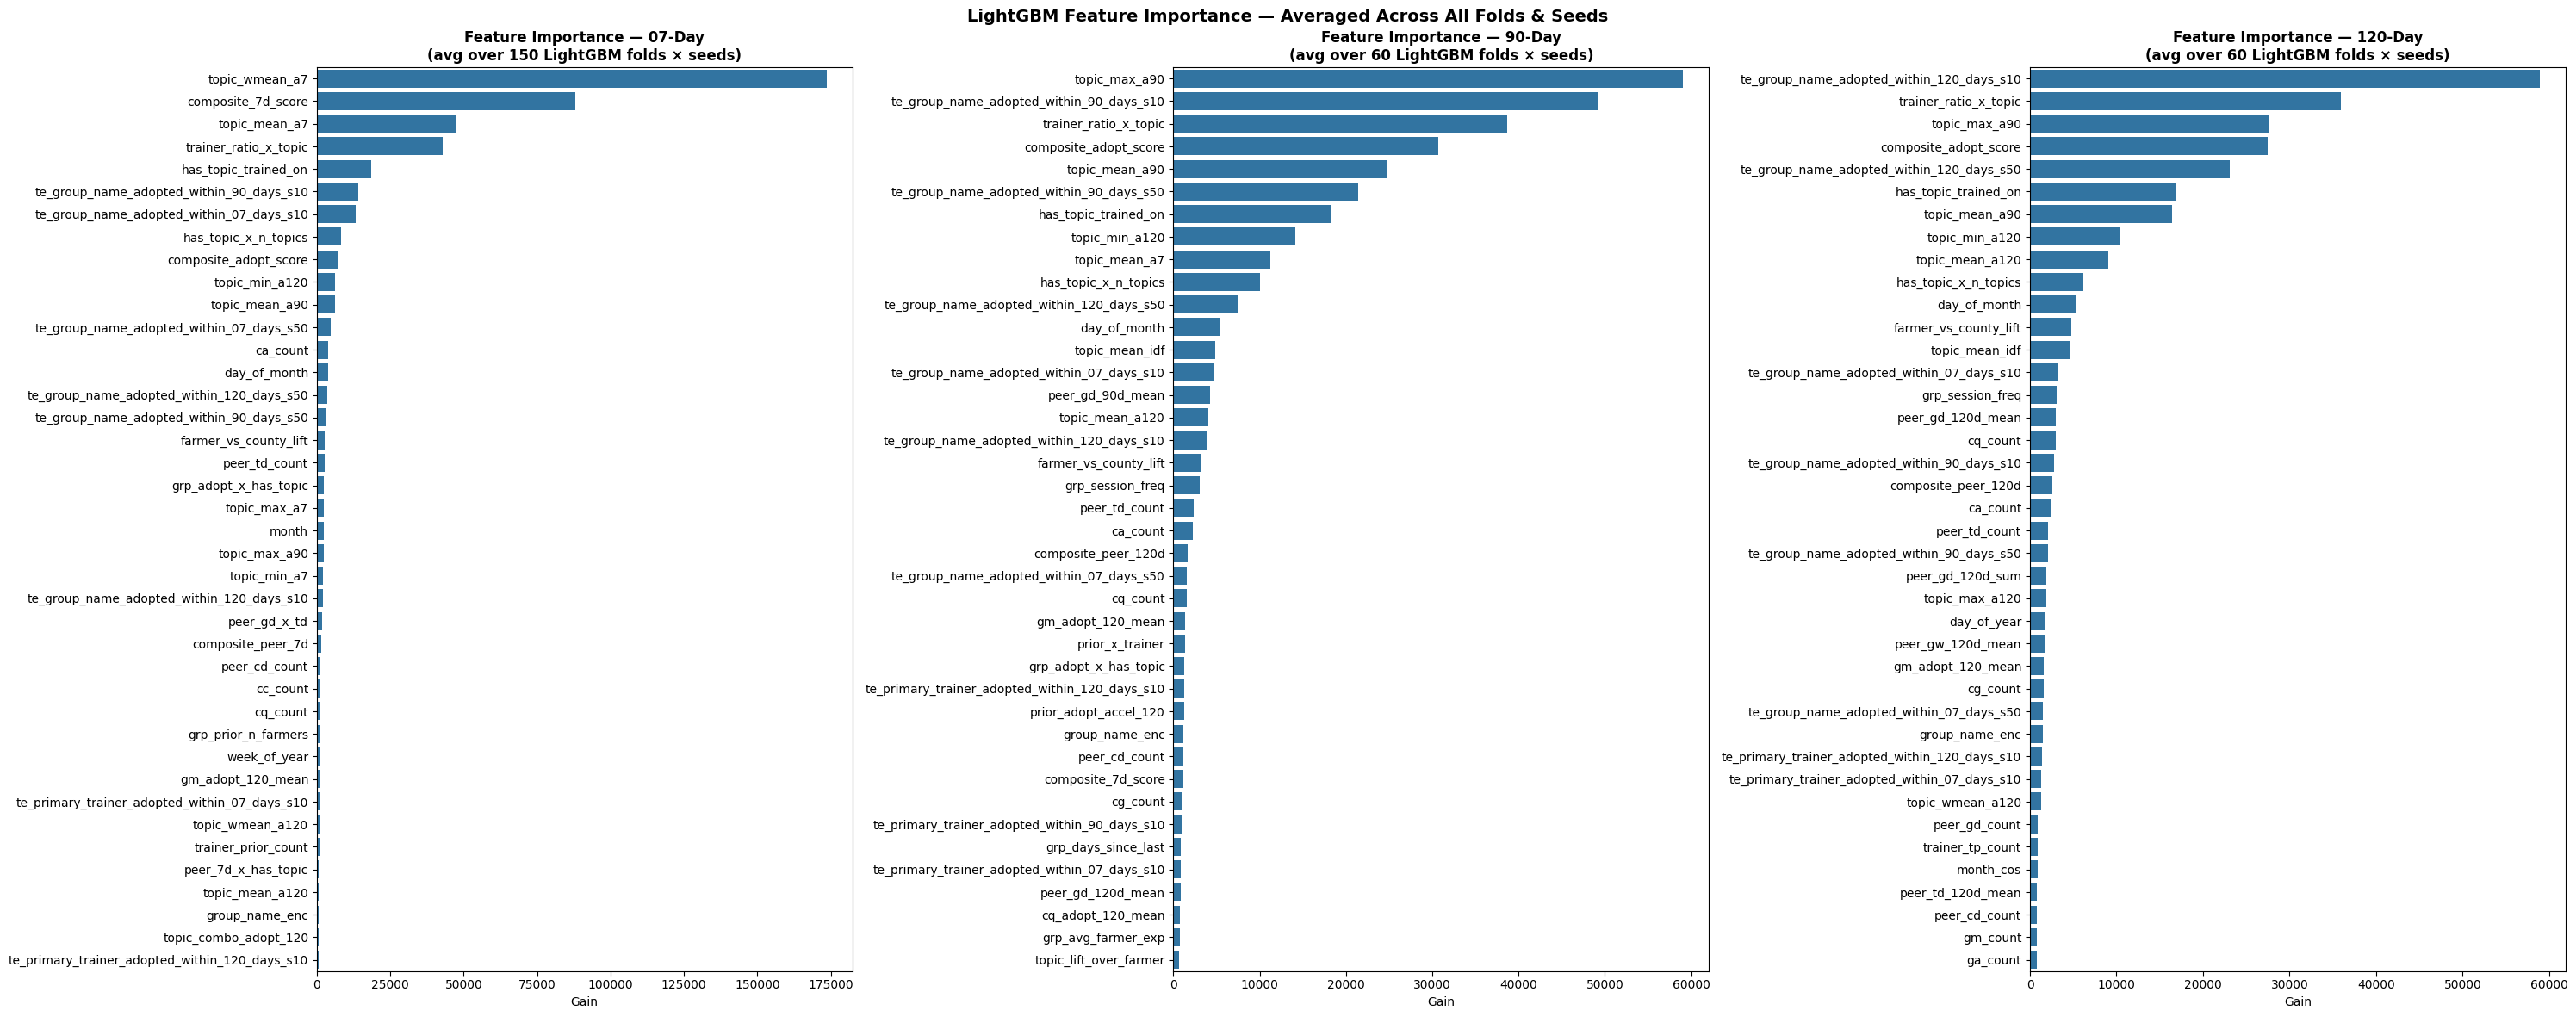

In [62]:

all_feature_names    = feature_cols + list(te_cols_train.keys())
feat_imp_accumulator = {t: np.zeros(len(all_feature_names)) for t in targets}
feat_imp_counts      = {t: 0 for t in targets}

test_predictions      = {}
all_oof_scores        = {}
oof_preds_per_target  = {}
test_preds_per_target = {}

for target in targets:
    ts = target_short[target]
    print(f"\n{'='*70}\nTraining: {target}\n{'='*70}")
    y         = train_feat[target].values
    pos_rate  = y.mean()
    scale_w   = (y==0).sum() / (y==1).sum()
    print(f"  Positive rate: {pos_rate:.4f}, scale_weight: {scale_w:.1f}")

    SEEDS    = SEEDS_BY_TARGET[target]
    is_7d    = (target == 'adopted_within_07_days')
    hgbt_cfgs= HGBT_CONFIGS + (HGBT_7D_EXTRA if is_7d else [])
    lgbm_cfgs= LGBM_CONFIGS + (LGBM_7D_EXTRA if is_7d else [])
    dart_cfgs= DART_CONFIGS + (DART_7D_EXTRA if is_7d else [])
    cb_cfgs  = CB_CONFIGS   + (CB_7D_EXTRA   if is_7d else [])
    n_models = len(hgbt_cfgs) + len(lgbm_cfgs) + len(dart_cfgs) + len(cb_cfgs) + 1
    print(f"  Model configs/seed: {n_models}, Seeds: {len(SEEDS)}")

    all_model_oof, all_model_test = [], []

    for seed in SEEDS:
        skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
        seed_oof  = [np.zeros(len(X_train)) for _ in range(n_models)]
        seed_test = [[] for _ in range(n_models)]

        for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
            X_tr, X_val = X_train[tr_idx], X_train[val_idx]
            y_tr, y_val = y[tr_idx],       y[val_idx]
            mi = 0

            # ── HistGradientBoosting ──
            for ci, (iters, lr, md, msl, mln, l2) in enumerate(hgbt_cfgs):
                m = HistGradientBoostingClassifier(
                    max_iter=iters, learning_rate=lr, max_depth=md,
                    min_samples_leaf=msl, max_leaf_nodes=mln, l2_regularization=l2,
                    early_stopping=True, validation_fraction=0.15, n_iter_no_change=60,
                    class_weight={0:1, 1:scale_w}, random_state=seed+ci*100+fold_idx)
                m.fit(X_tr, y_tr)
                seed_oof[mi][val_idx] = m.predict_proba(X_val)[:,1]
                seed_test[mi].append(m.predict_proba(X_test)[:,1])
                mi += 1

            # ── LightGBM GBDT ──
            for ci, (n_est, lr, md, nl, mc, rl, ss, cs) in enumerate(lgbm_cfgs):
                dtrain = lgb.Dataset(X_tr, label=y_tr)
                dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
                params = {'objective':'binary', 'metric':'binary_logloss',
                    'learning_rate':lr, 'max_depth':md, 'num_leaves':nl,
                    'min_child_samples':mc, 'lambda_l2':rl, 'subsample':ss,
                    'colsample_bytree':cs, 'scale_pos_weight':scale_w,
                    'verbosity':-1, 'seed':seed+ci*200+fold_idx, 'n_jobs':-1}
                m = lgb.train(params, dtrain, num_boost_round=n_est, valid_sets=[dval],
                    callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(0)])
                seed_oof[mi][val_idx] = m.predict(X_val)
                seed_test[mi].append(m.predict(X_test))
                # accumulate GBDT importance ──
                feat_imp_accumulator[target] += m.feature_importance(importance_type='gain')
                feat_imp_counts[target]      += 1
                mi += 1

            # ── LightGBM DART ──
            for ci, (n_est, lr, md, nl, mc, rl, dr, sd) in enumerate(dart_cfgs):
                dtrain = lgb.Dataset(X_tr, label=y_tr)
                dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
                params = {'objective':'binary', 'metric':'binary_logloss', 'boosting_type':'dart',
                    'learning_rate':lr, 'max_depth':md, 'num_leaves':nl,
                    'min_child_samples':mc, 'lambda_l2':rl, 'subsample':0.8,
                    'colsample_bytree':0.8, 'drop_rate':dr, 'skip_drop':sd,
                    'scale_pos_weight':scale_w, 'verbosity':-1,
                    'seed':seed+ci*400+fold_idx, 'n_jobs':-1}
                m = lgb.train(params, dtrain, num_boost_round=n_est, valid_sets=[dval],
                    callbacks=[lgb.log_evaluation(0)])
                seed_oof[mi][val_idx] = m.predict(X_val)
                seed_test[mi].append(m.predict(X_test))

                feat_imp_accumulator[target] += m.feature_importance(importance_type='gain')
                feat_imp_counts[target]      += 1
                mi += 1

            # ── CatBoost ──
            for ci, (iters, lr, depth, l2r, ss) in enumerate(cb_cfgs):
                m = cb.CatBoostClassifier(
                    iterations=iters, learning_rate=lr, depth=depth,
                    l2_leaf_reg=l2r, subsample=ss, scale_pos_weight=scale_w,
                    eval_metric='Logloss', early_stopping_rounds=60,
                    random_seed=seed+ci*300+fold_idx, verbose=0)
                m.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
                seed_oof[mi][val_idx] = m.predict_proba(X_val)[:,1]
                seed_test[mi].append(m.predict_proba(X_test)[:,1])
                mi += 1

            # ── Logistic Regression ──
            scaler   = StandardScaler()
            X_tr_sc  = scaler.fit_transform(X_tr)
            X_val_sc = scaler.transform(X_val)
            X_te_sc  = scaler.transform(X_test)
            m_lr = LogisticRegression(C=0.05, max_iter=3000, class_weight='balanced', solver='lbfgs')
            m_lr.fit(X_tr_sc, y_tr)
            seed_oof[mi][val_idx] = m_lr.predict_proba(X_val_sc)[:,1]
            seed_test[mi].append(m_lr.predict_proba(X_te_sc)[:,1])

        for mi_idx in range(n_models):
            all_model_oof.append(seed_oof[mi_idx])
            all_model_test.append(np.mean(seed_test[mi_idx], axis=0))

    # ── Blend optimization ──
    print(f"  Optimizing blend weights across {len(all_model_oof)} model×seed predictions...")
    opt_w, oof_blend  = optimize_blend_weights(all_model_oof, y)
    test_blend        = np.array(all_model_test).T @ opt_w
    print(f"  Blend OOF: LL={log_loss(y, np.clip(oof_blend,1e-7,1-1e-7)):.6f}, AUC={roc_auc_score(y, oof_blend):.6f}")

    # ── Calibration ──
    print(f"  Calibrating...")
    skf_cal = StratifiedKFold(n_splits=5, shuffle=True, random_state=999)
    oof_platt = np.zeros(len(y)); oof_beta = np.zeros(len(y)); oof_iso = np.zeros(len(y))
    test_platt_f, test_beta_f, test_iso_f = [], [], []

    for cal_tr, cal_val in skf_cal.split(oof_blend, y):
        oof_platt[cal_val] = platt_scaling(oof_blend[cal_tr], y[cal_tr], oof_blend[cal_val])
        test_platt_f.append(platt_scaling(oof_blend[cal_tr], y[cal_tr], test_blend))
        oof_beta[cal_val]  = beta_calibration(oof_blend[cal_tr], y[cal_tr], oof_blend[cal_val])
        test_beta_f.append(beta_calibration(oof_blend[cal_tr], y[cal_tr], test_blend))
        oof_iso[cal_val]   = isotonic_calibration(oof_blend[cal_tr], y[cal_tr], oof_blend[cal_val])
        test_iso_f.append(isotonic_calibration(oof_blend[cal_tr], y[cal_tr], test_blend))

    test_platt = np.mean(test_platt_f, axis=0)
    test_beta  = np.mean(test_beta_f,  axis=0)
    test_iso   = np.mean(test_iso_f,   axis=0)

    T        = find_temperature(oof_platt, y)
    oof_temp = temperature_scale(logit(np.clip(oof_platt, 1e-7, 1-1e-7)), T)
    test_temp= temperature_scale(logit(np.clip(test_platt, 1e-7, 1-1e-7)), T)

    def cal_obj(params):
        a, b = params
        c    = max(0.0, 1.0 - a - b)
        bl   = a*oof_temp + b*oof_beta + c*oof_iso
        return log_loss(y, np.clip(bl, 1e-7, 1-1e-7))

    cal_res = minimize(cal_obj, [0.5, 0.3], method='Nelder-Mead', options={'maxiter': 1000})
    a, b    = max(0, cal_res.x[0]), max(0, cal_res.x[1])
    c       = max(0, 1.0 - a - b)
    tot     = a + b + c; a /= tot; b /= tot; c /= tot
    print(f"  Calibration weights: {a:.3f}×PlattTemp + {b:.3f}×Beta + {c:.3f}×Isotonic  (T={T:.3f})")

    final_oof  = np.clip(a*oof_temp + b*oof_beta + c*oof_iso, 1e-7, 1-1e-7)
    final_test = np.clip(a*test_temp + b*test_beta + c*test_iso, 1e-7, 1-1e-7)

    oof_ll  = log_loss(y, final_oof)
    oof_auc = roc_auc_score(y, final_oof)
    all_oof_scores[target] = (oof_ll, oof_auc)
    print(f"  Final OOF: LL={oof_ll:.6f}, AUC={oof_auc:.6f}")

    oof_preds_per_target[target]  = final_oof
    test_preds_per_target[target] = final_test

#  Plot feature importance
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(30, 12))

for ax, target in zip(axes, targets):
    avg_imp = feat_imp_accumulator[target] / feat_imp_counts[target]

    feat_imp = pd.DataFrame({
        'feature':    all_feature_names,
        'importance': avg_imp
    }).sort_values('importance', ascending=False)

    print(f"\nTop 10 — {target_short[target]}-Day:")
    print(feat_imp.head(10).to_string(index=False))

    sns.barplot(x='importance', y='feature', data=feat_imp.head(40), ax=ax)
    ax.set_title(f'Feature Importance — {target_short[target]}-Day\n'
                 f'(avg over {feat_imp_counts[target]} LightGBM folds × seeds)',
                 fontweight='bold')
    ax.set_xlabel('Gain')
    ax.set_ylabel('')

plt.suptitle('LightGBM Feature Importance — Averaged Across All Folds & Seeds',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Stacking ( Meta-Model)


In [63]:
# Stack OOF predictions from all three targets as meta-features
meta_train = np.column_stack([oof_preds_per_target[t]  for t in targets])
meta_test  = np.column_stack([test_preds_per_target[t] for t in targets])

In [64]:
# Add contextual features (help meta-model personalise blending)
ctx_cols  = ['has_topic_trained_on', 'belong_to_cooperative', 'n_topics', 'age_enc', 'gender_enc']
ctx_cols  = [c for c in ctx_cols if c in train_feat.columns]
ctx_train = train_feat[ctx_cols].fillna(-1).values
ctx_test  = test_feat[ctx_cols].fillna(-1).values


In [65]:
# Add peer features (strongest signal from V13)
peer_cols  = ['peer_gd_7d_mean', 'peer_gd_120d_mean', 'peer_gd_any_7d', 'peer_gd_count',
              'peer_td_7d_mean', 'peer_gw_7d_mean', 'peer_gm_7d_mean',
              'composite_peer_7d', 'composite_peer_120d',
              'grp_tp_7d', 'trainer_tp_7d']
peer_cols  = [c for c in peer_cols if c in train_feat.columns]
peer_train = train_feat[peer_cols].fillna(-1).values
peer_test  = test_feat[peer_cols].fillna(-1).values

In [66]:
meta_train_full = np.hstack([meta_train, ctx_train, peer_train])
meta_test_full  = np.hstack([meta_test,  ctx_test,  peer_test])
print(f"Meta-feature matrix: {meta_train_full.shape}")

Meta-feature matrix: (13536, 19)


In [67]:
stacked_test = {}

for target in targets:
    y       = train_feat[target].values
    scale_w = (y==0).sum() / (y==1).sum()
    print(f"\n  Meta-model: {target}")

    skf_meta       = StratifiedKFold(n_splits=5, shuffle=True, random_state=777)
    meta_oof       = np.zeros(len(y))
    meta_test_preds= []

    for fold_idx, (tr_idx, val_idx) in enumerate(skf_meta.split(meta_train_full, y)):
        dtrain = lgb.Dataset(meta_train_full[tr_idx], label=y[tr_idx])
        dval   = lgb.Dataset(meta_train_full[val_idx], label=y[val_idx], reference=dtrain)
        params = {'objective':'binary', 'metric':'binary_logloss',
            'learning_rate':0.05, 'num_leaves':15, 'max_depth':4,
            'min_child_samples':20, 'lambda_l2':5.0, 'subsample':0.8,
            'colsample_bytree':0.8, 'scale_pos_weight':scale_w,
            'verbosity':-1, 'seed':42+fold_idx, 'n_jobs':-1}
        mm = lgb.train(params, dtrain, num_boost_round=500, valid_sets=[dval],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        meta_oof[val_idx] = mm.predict(meta_train_full[val_idx])
        meta_test_preds.append(mm.predict(meta_test_full))

    meta_test_avg = np.mean(meta_test_preds, axis=0)
    meta_ll  = log_loss(y, np.clip(meta_oof, 1e-7, 1-1e-7))
    meta_auc = roc_auc_score(y, meta_oof)
    base_ll  = all_oof_scores[target][0]
    print(f"    Meta OOF: LL={meta_ll:.6f} (base={base_ll:.6f}, improvement={base_ll-meta_ll:+.6f}), AUC={meta_auc:.6f}")

    # Find the optimal interpolation between meta predictions and base predictions
    res   = minimize_scalar(
        lambda a: log_loss(y, np.clip(a*meta_oof + (1-a)*oof_preds_per_target[target], 1e-7, 1-1e-7)),
        bounds=(0, 1), method='bounded')
    alpha = res.x
    print(f"    Blend: {alpha:.3f}×meta + {1-alpha:.3f}×base")

    s_oof  = np.clip(alpha*meta_oof       + (1-alpha)*oof_preds_per_target[target],  1e-7, 1-1e-7)
    s_test = np.clip(alpha*meta_test_avg  + (1-alpha)*test_preds_per_target[target], 1e-7, 1-1e-7)

    s_ll  = log_loss(y, s_oof)
    s_auc = roc_auc_score(y, s_oof)
    print(f"    Stacked final: LL={s_ll:.6f}, AUC={s_auc:.6f}")

    all_oof_scores[target] = (s_ll, s_auc)
    stacked_test[target]   = s_test


  Meta-model: adopted_within_07_days
    Meta OOF: LL=0.044232 (base=0.020453, improvement=-0.023779), AUC=0.975479
    Blend: 0.005×meta + 0.995×base
    Stacked final: LL=0.020448, AUC=0.991267

  Meta-model: adopted_within_90_days
    Meta OOF: LL=0.053934 (base=0.027401, improvement=-0.026533), AUC=0.963560
    Blend: 0.000×meta + 1.000×base
    Stacked final: LL=0.027401, AUC=0.988192

  Meta-model: adopted_within_120_days
    Meta OOF: LL=0.065508 (base=0.030665, improvement=-0.034843), AUC=0.975402
    Blend: 0.000×meta + 1.000×base
    Stacked final: LL=0.030665, AUC=0.987013


## Post-Processing


In [68]:
p7   = stacked_test['adopted_within_07_days'].copy()
p90  = stacked_test['adopted_within_90_days'].copy()
p120 = stacked_test['adopted_within_120_days'].copy()
global_7, global_90, global_120 = [train_feat[t].mean() for t in targets]

# 1. Hard rule: no topic → near-zero probability
no_topic   = test_feat['has_topic_trained_on'].values == 0
p7[no_topic] = p90[no_topic] = p120[no_topic] = 1e-7
print(f"  Hard rule applied to {no_topic.sum()} no-topic rows")

# 2. Enforce monotonicity: P(7d) ≤ P(90d) ≤ P(120d)
p90  = np.maximum(p90, p7)
p120 = np.maximum(p120, p90)

# 3. Mean recalibration: shift if test mean deviates >3% from training mean
for name, preds, glob in [('7d', p7, global_7), ('90d', p90, global_90), ('120d', p120, global_120)]:
    tm    = preds[~no_topic].mean()
    ratio = glob / tm if tm > 0 else 1.0
    print(f"  {name}: test_mean={tm:.6f}, train_mean={glob:.6f}, ratio={ratio:.4f}")
    if abs(ratio - 1) > 0.03:
        if name=='7d':   p7[~no_topic]   *= ratio
        elif name=='90d': p90[~no_topic]  *= ratio
        else:             p120[~no_topic] *= ratio
        print(f"Applied mean correction")

# Re-enforce monotonicity after recalibration
p90  = np.maximum(p90, p7)
p120 = np.maximum(p120, p90)
p7, p90, p120 = [np.clip(p, 1e-7, 1-1e-7) for p in [p7, p90, p120]]

  Hard rule applied to 24 no-topic rows
  7d: test_mean=0.011360, train_mean=0.011303, ratio=0.9950
  90d: test_mean=0.014141, train_mean=0.015810, ratio=1.1180
Applied mean correction
  120d: test_mean=0.016454, train_mean=0.022311, ratio=1.3559
Applied mean correction




Let's estimate our leaderboard score using the **competition's weighted formula**:
```
Score = 0.65 × (1 - LL_7d) + 0.15 × AUC_7d
      + 0.05 × (1 - LL_90d) + 0.05 × AUC_90d
      + 0.05 × (1 - LL_120d)+ 0.05 × AUC_120d
```

The 7-day target dominates (80% weight), so that's where the biggest gains come from.

In [69]:
total_score = 0.0
for target in targets:
    ll, auc = all_oof_scores[target]
    ts      = target_short[target]
    if target == 'adopted_within_07_days':   w_ll, w_auc = 0.65, 0.15
    elif target == 'adopted_within_90_days': w_ll, w_auc = 0.05, 0.05
    else:                                    w_ll, w_auc = 0.05, 0.05
    contribution = w_ll * (1 - ll) + w_auc * auc
    total_score += contribution
    print(f"  {ts}d: LL={ll:.6f} (w={w_ll}), AUC={auc:.6f} (w={w_auc}), contribution={contribution:.6f}")

print(f"\n TOTAL ESTIMATED LB SCORE: {total_score:.6f}")
print(f"  7-day contribution: {0.65*(1-all_oof_scores['adopted_within_07_days'][0]) + 0.15*all_oof_scores['adopted_within_07_days'][1]:.6f}")



  07d: LL=0.020448 (w=0.65), AUC=0.991267 (w=0.15), contribution=0.785399
  90d: LL=0.027401 (w=0.05), AUC=0.988192 (w=0.05), contribution=0.098040
  120d: LL=0.030665 (w=0.05), AUC=0.987013 (w=0.05), contribution=0.097817

 TOTAL ESTIMATED LB SCORE: 0.981256
  7-day contribution: 0.785399


In [70]:
submission = sub.copy()
submission['Target_07_AUC']      = p7
submission['Target_07_LogLoss']  = p7
submission['Target_90_AUC']      = p90
submission['Target_90_LogLoss']  = p90
submission['Target_120_AUC']     = p120
submission['Target_120_LogLoss'] = p120

In [71]:
print(f"\nSubmission shape: {submission.shape}")
for col, vals in [('07', p7), ('90', p90), ('120', p120)]:
    print(f"  Target_{col}: mean={vals.mean():.6f}, min={vals.min():.2e}, max={vals.max():.6f}")


Submission shape: (5621, 7)
  Target_07: mean=0.011311, min=1.00e-07, max=0.655113
  Target_90: mean=0.015742, min=1.00e-07, max=0.732414
  Target_120: mean=0.022216, min=1.00e-07, max=0.904162


In [72]:
submission.head()

,ID,Target_07_AUC,Target_90_AUC,Target_120_AUC,Target_07_LogLoss,Target_90_LogLoss,Target_120_LogLoss
0,ID_LEG1GM,0.000156,0.000417,0.000773,0.000156,0.000417,0.000773
1,ID_1UKOKW,0.000112,0.000245,0.000297,0.000112,0.000245,0.000297
2,ID_U5H2YK,0.022406,0.025050,0.030381,0.022406,0.025050,0.030381
3,ID_55957A,0.017433,0.019490,0.023638,0.017433,0.019490,0.023638
4,ID_N1AC0A,0.000109,0.000258,0.000312,0.000109,0.000258,0.000312


In [73]:
submission.to_csv('submission_v13.csv', index=False)